# Titanic：生存者と非生存者の比較

run_id: `v020-exp-01`。Kaggle公開データをSDKで取得し、記述・関連分析を行う。因果効果や全乗船者の代表値とは解釈しない。API資格情報は表示・保存しない。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, inspect, io, zipfile
from datetime import datetime, timezone
from contextlib import contextmanager, redirect_stdout, redirect_stderr
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router
PROJECT = 'kaggle-v020-kaggle-exp-01-titanic'
RUN_ID = 'v020-exp-01'
handle = pm.resolve_project(PROJECT)
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
language = language_router.detect_language('Titanicの生存者と非生存者の違いを分析してください。')
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(kind, label):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検出しました。')
    start = lifecycle.mark_execution_start if kind == 'execution' else lifecycle.mark_write_start
    end = lifecycle.mark_execution_end if kind == 'execution' else lifecycle.mark_write_end
    start(RUN_ID)
    phase_log.append({'phase':kind, 'label':label, 'event':'start', 'at':datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase':kind, 'label':label, 'event':'failed'})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase':kind, 'label':label, 'event':'end', 'at':datetime.now(timezone.utc).isoformat()})
def write_notebook(mutation, label='notebook write'):
    with phase('write', label):
        return pm.enqueue_write(handle, mutation)
def put_cells(specifications):
    def mutation(nb):
        for cell_id, cell_type, source in specifications:
            old = next((c for c in nb.cells if c.id == cell_id), None)
            if old is None:
                cell = nbformat.v4.new_code_cell(source) if cell_type == 'code' else nbformat.v4.new_markdown_cell(source)
                cell.id = cell_id
                nb.cells.append(cell)
            elif old.source != source:
                raise RuntimeError(f'既存セルと内容が異なります: {cell_id}')
    write_notebook(mutation, 'セル追加')
def emit(obj):
    text = obj if isinstance(obj, str) else json.dumps(obj, ensure_ascii=False, indent=2, default=str)
    display({'text/plain':text}, raw=True)
print('run_id:', RUN_ID, 'language:', language)
print('Notebook:', handle.notebook_path)
print('lifecycle:', asdict(lifecycle.get_run_status(RUN_ID)))
from kaggle.api.kaggle_api_extended import KaggleApi
print('Kaggle SDK signatures:')
for name in ['dataset_list','dataset_list_files','dataset_download_file']:
    print(name, inspect.signature(getattr(KaggleApi, name)))
from IPython import get_ipython
from IPython.utils.capture import capture_output
@contextmanager
def recorded_cell(cell_id, label):
    # liveセル中の外部保存でMCP出力が失われるため、実出力を同じセルへ明示保存する。
    with capture_output() as captured:
        with phase('execution', label):
            yield
    count = get_ipython().execution_count
    outputs = []
    if captured.stdout:
        outputs.append(nbformat.v4.new_output('stream', name='stdout', text=captured.stdout))
    if captured.stderr:
        outputs.append(nbformat.v4.new_output('stream', name='stderr', text=captured.stderr))
    for rich in captured.outputs:
        outputs.append(nbformat.v4.new_output('display_data', data=rich.data, metadata=rich.metadata))
    def persist(nb):
        current = next(c for c in nb.cells if c.id == cell_id)
        current.execution_count = count
        current.outputs = outputs
    write_notebook(persist, '実行済みセル出力保存:' + cell_id)
    captured.show()


run_id: v020-exp-01 language: ja
Notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb
lifecycle: {'run_id': 'v020-exp-01', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb', 'reason': None}
Kaggle SDK signatures:
dataset_list (self, sort_by: Optional[str] = None, size: Optional[str] = None, file_type: Optional[str] = None, license_name: Optional[str] = None, tag_ids: Optional[str] = None, search: Optional[str] = None, user: Optional[str] = None, mine: Optional[bool] = False, page: Optional[int] = 1, max_size: Optional[str] = None, min_size: Optional[str] = None) -> list[kagglesdk.datasets.types.dataset_api_service.ApiDataset | None] | None
dataset_list_files (self, dataset, page_token=None, page

## 分析計画（データを見る前）

1. Kaggle SDKのauthenticate、dataset_list、dataset_list_filesで公開データを検索。目的変数Survivedを含む競技train.csv相当だけを採用し、test.csvやgender_submission.csvを真の生存ラベルとして使わない。適合しなければ実験停止（外部ミラー禁止）。取得slug、ファイル名、日時、SHA-256を記録する。
2. データ定義と分析前提のmanifestを作り、行数、欠損、重複、値域・カテゴリを検査する。欠損行の一括除去や運賃外れ値の機械的除去はしない。
3. 生存/非生存別の構成比・年齢/運賃分布と、性別・等級・年齢帯・家族人数・乗船港・客室欠損別の生存率を比較する。分母、Wilson 95%区間、差の大きさを示し、性別×等級で交絡を見る。多重比較のp値だけで順位づけしない。
4. 生存率の比較図、性別×等級図、年齢・運賃の分布図を選ぶ。区間・分母と軸の意味を記録しvisual_audit=Trueで監査する。
5. 初回結果を読み直し、重要な未解決点だけ追加依頼として原文記録する（最大3回）。年齢欠損・層別・運賃/家族依存などを必要に応じ検証する。SensitivityPlanで有意な仕様変更を評価する。
6. 根拠セルに結びつくInsight、限界、直接使用モジュール、改善候補を記録。最後にカーネルを再起動し全コードセルを上から再実行し、監査とcompleted/failed状態を保存する。

実行はJupyter MCPのみ。Notebook内容の明示的な追加・更新はproject_manager.enqueue_writeで直列化する。初期接続用セルと実行結果の保存はJupyter MCPのNotebook保存機能が担当する。mcp_gateway.run_and_recordはこのホストからPython MCPClientが公開されず、同一カーネルへの再入実行も避けるため直接呼ばない。偽の実行クライアントは作らない。

In [3]:
# Kaggle公開データの検索（資格情報は一切表示しない）
with recorded_cell('kaggle-discovery', 'Kaggle公開データ検索'):
    api = KaggleApi()
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            api.authenticate()
            candidates = api.dataset_list(search='titanic', sort_by='hottest', page=1)
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle認証/検索に失敗。外部ソースにはフォールバックしません。例外種別: ' + type(exc).__name__) from None
    candidate_rows = [{'slug': d.ref, 'title': d.title} for d in (candidates or [])]
    if not candidate_rows:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('KaggleでTitanic公開データが見つかりません。実験停止。')
    emit({'検索語':'titanic', '候補':candidate_rows})
    preferred = ['heptapod/titanic', 'yasserh/titanic-dataset', 'azeembootwala/titanic']
    refs = [r['slug'] for r in candidate_rows]
    discovery_files = []
    selected_slug = None
    selected_file = None
    for slug in [s for s in preferred if s in refs] + [s for s in refs if s not in preferred]:
        try:
            with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                listing = api.dataset_list_files(slug)
        except Exception as exc:
            lifecycle.mark_failed(RUN_ID)
            raise RuntimeError('Kaggleファイル一覧取得に失敗: ' + slug + ' / ' + type(exc).__name__) from None
        filenames = [f.name for f in listing.files]
        discovery_files.append({'slug':slug, 'files':filenames})
        matches = [f for f in filenames if Path(f).name.lower() in ('train.csv','titanic.csv','titanic-dataset.csv')]
        if matches:
            selected_slug, selected_file = slug, sorted(matches, key=lambda s: Path(s).name.lower() != 'train.csv')[0]
            break
    emit({'ファイル一覧確認':discovery_files, '選択slug':selected_slug, '選択ファイル':selected_file})
    if selected_slug is None:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('対応する公開CSVが見つからないため実験停止。外部ミラーは使いません。')


{
  "検索語": "titanic",
  "候補": [
    {
      "slug": "heptapod/titanic",
      "title": "Titanic"
    },
    {
      "slug": "brendan45774/test-file",
      "title": "Titanic dataset"
    },
    {
      "slug": "yasserh/titanic-dataset",
      "title": "Titanic Dataset"
    },
    {
      "slug": "azeembootwala/titanic",
      "title": "Titanic"
    },
    {
      "slug": "rahulsah06/titanic",
      "title": "Titanic "
    },
    {
      "slug": "sakshisatre/titanic-dataset",
      "title": "Titanic Dataset"
    },
    {
      "slug": "shubhamgupta012/titanic-dataset",
      "title": "Titanic Dataset"
    },
    {
      "slug": "ibrahimelsayed182/titanic-dataset",
      "title": "Titanic dataset"
    },
    {
      "slug": "waqi786/titanic-dataset",
      "title": "Titanic Dataset"
    },
    {
      "slug": "lovishbansal123/titanic-dataset",
      "title": "Titanic Dataset"
    },
    {
      "slug": "fossouodonald/titaniccsv",
      "title": "Titanic csv"
    },
    {
      "slug": "a

{
  "ファイル一覧確認": [
    {
      "slug": "heptapod/titanic",
      "files": [
        "train_and_test2.csv"
      ]
    },
    {
      "slug": "yasserh/titanic-dataset",
      "files": [
        "Titanic-Dataset.csv"
      ]
    }
  ],
  "選択slug": "yasserh/titanic-dataset",
  "選択ファイル": "Titanic-Dataset.csv"
}

In [4]:
import pandas as pd
import numpy as np
from ai_data_scientist import ingestion, cleaning, eda
with recorded_cell('download-ingest', 'Kaggle取得・検証'):
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            downloaded = api.dataset_download_file(selected_slug, selected_file, path=str(data_dir), force=True, quiet=True)
    except Exception as exc:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggleダウンロードに失敗。外部フォールバックなし。例外種別: ' + type(exc).__name__) from None
    csv_path = data_dir / Path(selected_file).name
    zip_path = Path(str(csv_path) + '.zip')
    if not csv_path.exists() and zip_path.exists():
        with zipfile.ZipFile(zip_path) as archive:
            matches = [n for n in archive.namelist() if Path(n).name == csv_path.name]
            if len(matches) != 1:
                raise RuntimeError('ダウンロードZIPのCSV同定に失敗。')
            csv_path.write_bytes(archive.read(matches[0]))
    if not csv_path.exists():
        raise RuntimeError('Kaggle SDK取得ファイルが見つかりません。')
    provenance = {'competition_reference':'https://www.kaggle.com/competitions/titanic',
                  'dataset_url':'https://www.kaggle.com/datasets/' + selected_slug,
                  'owner_dataset_slug':selected_slug, 'filename':selected_file,
                  'retrieved_at_utc':datetime.now(timezone.utc).isoformat(),
                  'sha256':hashlib.sha256(csv_path.read_bytes()).hexdigest(),
                  'acquisition':'Kaggle Python SDK / dataset_download_file', 'external_csv_mirror':False}
    loaded = ingestion.ingest(ingestion.SourceSpec('csv', str(csv_path)), row_limit=10000)
    raw = loaded.dataframe
    expected_columns = ['PassengerId','Survived','Pclass','Name','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked']
    if list(raw.columns) != expected_columns or len(raw) != 891 or set(raw.Survived.dropna().unique()) != {0,1}:
        raise RuntimeError('競技train.csv相当の構造・ラベルを確認できません。実験停止。')
    if raw.PassengerId.tolist() != list(range(1,892)) or raw.Survived.value_counts().to_dict() != {0:549,1:342}:
        raise RuntimeError('競技train.csv相当のID/ラベル整合性を確認できません。実験停止。')
    cleaned = cleaning.clean_dataset(raw, operation='drop_duplicates')
    df = cleaned.dataframe.copy()
    emit(provenance)
    emit({'shape':list(df.shape), 'ingestion_truncated':loaded.truncated,
          'rows_before':cleaned.rows_before, 'rows_after':cleaned.rows_after,
          'rows_removed':cleaned.rows_removed, 'columns_affected':cleaned.columns_affected,
          'identity_note':'既知の競技訓練データ構造とID/ラベル集計に整合。ただし競技原本とのバイト照合や歴史的記録の独立検証ではない。'})
    eda_report = eda.explore(df.drop(columns=['Name','Ticket','Cabin']), top_n=5)
    emit({'EDA':asdict(eda_report), 'all_missing':df.isna().sum().to_dict()})


{
  "competition_reference": "https://www.kaggle.com/competitions/titanic",
  "dataset_url": "https://www.kaggle.com/datasets/yasserh/titanic-dataset",
  "owner_dataset_slug": "yasserh/titanic-dataset",
  "filename": "Titanic-Dataset.csv",
  "retrieved_at_utc": "2026-10-01T15:45:35.352734+00:00",
  "sha256": "7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f",
  "acquisition": "Kaggle Python SDK / dataset_download_file",
  "external_csv_mirror": false
}

{
  "shape": [
    891,
    12
  ],
  "ingestion_truncated": false,
  "rows_before": 891,
  "rows_after": 891,
  "rows_removed": 0,
  "columns_affected": [
    "PassengerId",
    "Survived",
    "Pclass",
    "Name",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked"
  ],
  "identity_note": "既知の競技訓練データ構造とID/ラベル集計に整合。ただし競技原本とのバイト照合や歴史的記録の独立検証ではない。"
}

{
  "EDA": {
    "describe": {
      "PassengerId": {
        "count": 891.0,
        "mean": 446.0,
        "std": 257.3538420152301,
        "min": 1.0,
        "25%": 223.5,
        "50%": 446.0,
        "75%": 668.5,
        "max": 891.0
      },
      "Survived": {
        "count": 891.0,
        "mean": 0.3838383838383838,
        "std": 0.4865924542648575,
        "min": 0.0,
        "25%": 0.0,
        "50%": 0.0,
        "75%": 1.0,
        "max": 1.0
      },
      "Pclass": {
        "count": 891.0,
        "mean": 2.308641975308642,
        "std": 0.836071240977049,
        "min": 1.0,
        "25%": 2.0,
        "50%": 3.0,
        "75%": 3.0,
        "max": 3.0
      },
      "Age": {
        "count": 714.0,
        "mean": 29.69911764705882,
        "std": 14.526497332334042,
        "min": 0.42,
        "25%": 20.125,
        "50%": 28.0,
        "75%": 38.0,
        "max": 80.0
      },
      "SibSp": {
        "count": 891.0,
        "mean": 0.5230078563411896,
      

In [5]:
# SDKが提供する公開データセット記述を取得（外部CSVは使用しない）
with recorded_cell('dataset-dictionary', 'Kaggle公開メタデータ取得'):
    try:
        with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
            api.dataset_metadata(selected_slug, str(data_dir))
    except Exception as exc:
        raise RuntimeError('Kaggle公開メタデータ取得失敗: ' + type(exc).__name__) from None
    public_metadata_path = data_dir / 'dataset-metadata.json'
    public_metadata_envelope = json.loads(public_metadata_path.read_text(encoding='utf-8'))
    public_metadata = public_metadata_envelope.get('info', public_metadata_envelope)
    dataset_description = public_metadata.get('description', '')
    emit({'title':public_metadata.get('title'), 'id':public_metadata.get('id'),
          'licenses':public_metadata.get('licenses'), 'description':dataset_description})


{
  "title": "Titanic Dataset",
  "id": null,
  "licenses": [
    {
      "name": "CC0-1.0"
    }
  ],
  "description": "![](https://raw.githubusercontent.com/Masterx-AI/Project_Titanic_Survival_Prediction_/main/titanic.jpg)\n\n### Description:\n\nThe sinking of the Titanic is one of the most infamous shipwrecks in history.\n\nOn April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.\n\nWhile there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.\n\nIn this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).\n\n\n### Acknowledgements:\nThis dataset has been referred fr

In [6]:
from ai_data_scientist import data_definition, analysis_assumptions, data_quality
from ai_data_scientist.data_definition import FieldValue
with recorded_cell('manifests-quality', '定義・前提・意味的品質検査'):
    dictionary_source = provenance['dataset_url'] + '（SDK公開description、列名と実測値）'
    definitions = {
        'PassengerId':('乗客行ID。歴史的な原簿番号とは確認できない','識別子'),
        'Survived':('生存ラベル: 0=非生存、1=生存','二値'),
        'Pclass':('客室等級コード: 1/2/3。資産・所得そのものではない','順序カテゴリ'),
        'Name':('乗客名（解析の説明変数には使わない）','文字列'),
        'Sex':('データに記録されたfemale/male','カテゴリ'),
        'Age':('年齢、端数は乳幼児等の年齢表現と推定','年（推定）'),
        'SibSp':('同乗したきょうだい/配偶者数と推定','人数'),
        'Parch':('同乗した親/子の数と推定','人数'),
        'Ticket':('乗船券識別文字列。共有券は依存性の代理とする','文字列'),
        'Fare':('記録された運賃。個人負担か共有券総額か未確認','通貨単位未確認'),
        'Cabin':('客室識別文字列。欠損は客室なしとは意味しない','文字列'),
        'Embarked':('乗船港コードC/Q/S。港名の対応は未確認','カテゴリ')}
    variable_manifest = {k:{'definition':FieldValue(v[0], 'inferred', dictionary_source),
                            'unit':FieldValue(v[1], 'unknown' if k=='Fare' else 'inferred', dictionary_source)}
                         for k,v in definitions.items()}
    definition_manifest = data_definition.build_manifest(
        source={k:FieldValue(v,'verified','SDK取得/ハッシュ計算') for k,v in provenance.items()} | {
            'license':FieldValue(public_metadata.get('licenses'), 'verified', 'Kaggle SDK公開メタデータ'),
            'measurement_pathway':FieldValue(None,'unknown','歴史的記録の収集・改訂過程は未取得')},
        dataset_scope={'n':FieldValue(len(df),'verified','CSV行数'),
                       'scope':FieldValue('競技訓練データ相当の乗客標本。全乗客・乗員ではない','inferred','公開descriptionと構造'),
                       'competition_origin_claim':FieldValue('Kaggle Titanic競技由来と公開descriptionに明記','verified','SDK公開description')},
        variables=variable_manifest,
        transformations=('完全一致行の重複除去（除去0行）','全行保持、年齢欠損は区別','派生人数=1+SibSp+Parch'))
    unknown_fields = [(p,asdict(v)) for p,v in definition_manifest.unresolved_fields()]
    inferred_fields = [(f'variables.{k}.{f}',asdict(v)) for k,fields in definition_manifest.variables.items() for f,v in fields.items() if v.status=='inferred']
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'population':'取得した891行に限定','target':'生存群と非生存群の構成・関連の比較','interval':'独立Bernoulli近似のWilson 95%区間。共有券依存は追加検査予定'},
        assumptions=(
            analysis_assumptions.Assumption('train-identity','公開descriptionの競技由来記述と構造/ID/ラベル集計が整合','tested',impact_if_false='別データを解析する',conclusion_critical=True),
            analysis_assumptions.Assumption('semantic-coding','生存コード・等級・年齢・家族定義は標準Titanic慣行に従うが詳細辞書との独立照合は未完','assumed',impact_if_false='列の意味に基づく解釈が変わる',conclusion_critical=True),
            analysis_assumptions.Assumption('no-global-drop','欠損を含む全行を残し年齢比較だけ観測値を使う','verified',conclusion_critical=True),
            analysis_assumptions.Assumption('independent-passengers','単純率区間の乗客独立性は共有券により破れる可能性','assumed',impact_if_false='区間が狭すぎる。点推定は記述値として維持',conclusion_critical=True),
            analysis_assumptions.Assumption('no-causal','交絡や選択を完全には制御できず因果効果は識別しない','verified',conclusion_critical=True)),
        causal_scope='associational', sampling={'n':len(df),'seed':20261002,'method':'取得データ全行、無作為抽出はしない'})
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    schema = {'PassengerId':{'not_null':True,'unique':True,'min':1},
              'Survived':{'not_null':True,'allowed':[0,1]}, 'Pclass':{'not_null':True,'allowed':[1,2,3]},
              'Sex':{'not_null':True,'allowed':['female','male']}, 'Age':{'min':0,'max':120},
              'SibSp':{'not_null':True,'min':0,'max':20}, 'Parch':{'not_null':True,'min':0,'max':20},
              'Fare':{'not_null':True,'min':0}, 'Embarked':{'allowed':['C','Q','S']}}
    missing_schema_columns = sorted(set(schema)-set(df.columns))
    if missing_schema_columns:
        raise RuntimeError('必須列がありません: ' + str(missing_schema_columns))
    semantic_anomalies = data_quality.detect_anomalies(df, schema=schema)
    integer_violations = {c:int((df[c].dropna()%1 != 0).sum()) for c in ['PassengerId','Survived','Pclass','SibSp','Parch']}
    emit({'data_definition_manifest':asdict(definition_manifest), 'unknown_fields':unknown_fields,
          'inferred_fields_caveat':inferred_fields, 'analysis_assumption_manifest':asdict(assumption_manifest),
          'assumption_findings':[asdict(f) for f in assumption_findings],
          'semantic_anomalies':[asdict(a) for a in semantic_anomalies], 'integer_violations':integer_violations,
          'diagnostic_non_errors':{'Fare=0':int((df.Fare==0).sum()),'Fare>200':int((df.Fare>200).sum()),
                                   'shared_Ticket_rows':int(df.Ticket.duplicated(keep=False).sum())}})
    if semantic_anomalies or any(integer_violations.values()):
        raise RuntimeError('意味的制約違反があるため解釈を停止します。')
    def save_manifests(nb):
        previous = nb.metadata.get('provenance')
        if previous and (previous['sha256'] != provenance['sha256'] or previous['owner_dataset_slug'] != selected_slug):
            raise RuntimeError('再取得データが初回と異なります。Insightを再利用せず停止します。')
        if not previous:
            nb.metadata['provenance'] = provenance
        nb.metadata['last_acquisition'] = provenance
        nb.metadata['data_definition_manifest'] = json.loads(json.dumps(asdict(definition_manifest),default=str))
        nb.metadata['analysis_assumption_manifest'] = asdict(assumption_manifest)
    write_notebook(save_manifests,'manifest/取得履歴保存')


{
  "data_definition_manifest": {
    "source": {
      "competition_reference": {
        "value": "https://www.kaggle.com/competitions/titanic",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
      "dataset_url": {
        "value": "https://www.kaggle.com/datasets/yasserh/titanic-dataset",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
      "owner_dataset_slug": {
        "value": "yasserh/titanic-dataset",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
      "filename": {
        "value": "Titanic-Dataset.csv",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
      "retrieved_at_utc": {
        "value": "2026-10-01T15:45:35.352734+00:00",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
      "sha256": {
        "value": "7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f",
        "status": "verified",
        "source": "SDK取得/ハッシュ計算"
      },
    

## 定義・前提・適用範囲

公開メタデータは競技由来を明記しているが詳細データ辞書は含まれない。列の詳細な意味はinferred、運賃通貨・個人/共有券の負担単位と歴史的収集経路はunknown。未知だけでなく推定フィールドも上の出力で列挙した。性別等のコード解釈を誤ると結論が変わるため未検証前提として明示する。

年齢欠損の無作為性は仮定しない。欠損一括除去・運賃ゼロや高額値の自動除去をしない。客室記録あり/なしは記録パターンであり客室の有無や船内位置の直接比較ではない。家族人数は本人+SibSp+Parchの代理で、友人・使用人など全同行者数ではない。

独立参照データがなく、同じ競技の複製を独立検証に見せることは避ける。data_quality.validate_anomalies、dataset_validation.compare_datasetsは適用不可（未呼出し）。因果識別・全乗船者への一般化・予測モデル評価も目的外。Wilson区間は仮想反復標本の近似で、この標本の記述値そのものの誤差ではなく、共有券依存と選択バイアスも解決しない。

Kaggle SDK固有の補足：dataset_viewはこのバージョンに存在しなかったためdataset_metadataを使用した。JSONはinfo下に格納される。これはJupytermindの不具合候補ではない。公開description中の外部画像URLは取得していない。

In [7]:
from scipy.stats import norm
from ai_data_scientist import stats_analysis
with recorded_cell('initial-comparisons', '初回比較表'):
    df['FamilySize'] = 1 + df.SibSp + df.Parch
    df['FamilyGroup'] = pd.cut(df.FamilySize, bins=[0,1,4,np.inf], labels=['Alone','2-4','5+']).astype('str')
    df['AgeBand'] = pd.cut(df.Age, bins=[0,12,18,35,60,np.inf], right=False,
                           labels=['0-11','12-17','18-34','35-59','60+']).astype('str')
    df.loc[df.Age.isna(),'AgeBand'] = 'Missing'
    df['CabinRecorded'] = np.where(df.Cabin.notna(),'Recorded','Missing')
    df['Port'] = df.Embarked.fillna('Missing')
    def rates(data, columns):
        table = data.groupby(columns, observed=True, dropna=False).Survived.agg(n='size', survivors='sum')
        table['rate'] = table.survivors/table.n
        z = norm.ppf(0.975)
        center = (table.rate+z*z/(2*table.n))/(1+z*z/table.n)
        half = z*np.sqrt(table.rate*(1-table.rate)/table.n+z*z/(4*table.n**2))/(1+z*z/table.n)
        table['ci_low'], table['ci_high'] = center-half, center+half
        return table.reset_index()
    rate_tables = {c:rates(df,[c]) for c in ['Sex','Pclass','AgeBand','FamilyGroup','Port','CabinRecorded']}
    overall = {'n':len(df),'survived':int(df.Survived.sum()),'non_survived':int((df.Survived==0).sum()),'survival_rate':float(df.Survived.mean())}
    emit({'overall':overall})
    for c,t in rate_tables.items():
        emit('生存率（分母・生存数・Wilson 95%区間）: ' + c)
        display(t.round(6))
    sex_class = rates(df,['Sex','Pclass'])
    emit('性別×等級の生存率')
    display(sex_class.round(6))
    numeric_summary = df.groupby('Survived')[['Age','Fare','FamilySize']].agg(['count','mean','median',lambda x:x.quantile(.25),lambda x:x.quantile(.75)])
    emit('生存群/非生存群の連続値：順にn/平均/中央値/Q1/Q3')
    display(numeric_summary.round(4))
    composition = pd.crosstab(df.Sex, df.Survived, normalize='columns')
    emit('生存群/非生存群に占める性別構成比（生存率とは分母が異なる）')
    display(composition.round(6))
    fare_correlation = stats_analysis.correlation(df,'Fare','Survived',language=language)
    emit({'fare_correlation':asdict(fare_correlation)})
    initial_metrics = {'女性生存率_pct':100*df.loc[df.Sex=='female','Survived'].mean(),
                       '男性生存率_pct':100*df.loc[df.Sex=='male','Survived'].mean(),
                       '性別差_pp':100*(df.loc[df.Sex=='female','Survived'].mean()-df.loc[df.Sex=='male','Survived'].mean()),
                       '等級1生存率_pct':100*df.loc[df.Pclass==1,'Survived'].mean(),
                       '等級3生存率_pct':100*df.loc[df.Pclass==3,'Survived'].mean(),
                       '生存群運賃中央値':df.loc[df.Survived==1,'Fare'].median(),
                       '非生存群運賃中央値':df.loc[df.Survived==0,'Fare'].median(),
                       '年齢欠損_pct':100*df.Age.isna().mean()}
    emit('INITIAL_METRICS=' + json.dumps(initial_metrics,ensure_ascii=False,sort_keys=True))


{
  "overall": {
    "n": 891,
    "survived": 342,
    "non_survived": 549,
    "survival_rate": 0.3838383838383838
  }
}

生存率（分母・生存数・Wilson 95%区間）: Sex

,Sex,n,survivors,rate,ci_low,ci_high
0,female,314,233,0.742038,0.690925,0.787301
1,male,577,109,0.188908,0.159066,0.222865


生存率（分母・生存数・Wilson 95%区間）: Pclass

,Pclass,n,survivors,rate,ci_low,ci_high
0,1,216,136,0.629630,0.563490,0.691239
1,2,184,87,0.472826,0.401983,0.544781
2,3,491,119,0.242363,0.206554,0.282171


...

Age                                        Fare                  \
         count     mean median <lambda_0> <lambda_1> count     mean median   
Survived                                                                     
0          424  30.6262   28.0       21.0       39.0   549  22.1179   10.5   
1          290  28.3437   28.0       19.0       36.0   342  48.3954   26.0   

                               FamilySize                                       
         <lambda_0> <lambda_1>      count    mean median <lambda_0> <lambda_1>  
Survived                                                                        
0            7.8542       26.0        549  1.8834    1.0        1.0        2.0  
1           12.4750       57.0        342  1.9386    2.0        1.0        3.0

生存群/非生存群に占める性別構成比（生存率とは分母が異なる）

Survived,0,1
Sex,,
female,0.147541,0.681287
male,0.852459,0.318713


{
  "fare_correlation": {
    "statistic": 0.2573065223849624,
    "p_value": 6.12018934192415e-15,
    "interpretation": "相関係数は 0.2573 (p=6.12e-15) で、弱い正の相関が見られます。"
  }
}

INITIAL_METRICS={"女性生存率_pct": 74.20382165605095, "年齢欠損_pct": 19.865319865319865, "性別差_pp": 55.31300709799203, "生存群運賃中央値": 26.0, "男性生存率_pct": 18.890814558058924, "等級1生存率_pct": 62.96296296296296, "等級3生存率_pct": 24.236252545824847, "非生存群運賃中央値": 10.5}

In [8]:
from ai_data_scientist import insight_engine
with recorded_cell('evidence-tools','根拠保存ヘルパー準備'):
    def evidence_for(cell_id, pattern):
        notebook=nbformat.read(handle.notebook_path,as_version=4)
        cell=next(c for c in notebook.cells if c.id==cell_id)
        output='\n'.join(str(o.get('data',{}).get('text/plain','')) for o in cell.outputs)
        result={'output':output,'execution_count':cell.execution_count}
        cited=insight_engine.extract_cited_value(result,pattern)
        return result['execution_count'],cited
    def save_insight(insight_id, anchor_id, text, source_id, pattern, claim='associational'):
        count,cited=evidence_for(source_id,pattern)
        def remove_previous(nb):
            nb.cells=[c for c in nb.cells if c.id!=insight_id]
        write_notebook(remove_previous,'Insight旧版更新:'+insight_id)
        with phase('write','根拠付きInsight:'+insight_id):
            insight_engine.record_insight(handle,text,count,cited,claim,language=language)
        write_notebook(lambda nb:setattr(nb.cells[-1],'id',insight_id),'Insight ID保存:'+insight_id)
    emit('根拠は実出力から抽出。Insightを末尾に配置し実行中コードの位置を変更しない。')


根拠は実出力から抽出。Insightを末尾に配置し実行中コードの位置を変更しない。

In [9]:
with recorded_cell('initial-insights','初回Insight記録'):
    count,initial_cited = evidence_for('initial-comparisons',r'INITIAL_METRICS=(.+)')
    initial_text = ('初回Insight：生存342人/非生存549人。女性生存率74.2%（233/314）、男性18.9%（109/577）で55.3ポイント差。'
                    '生存群の68.1%が女性、非生存群の85.2%が男性。1等63.0%、2等47.3%、3等24.2%で、女性1等96.8%/3等50.0%、男性1等36.9%/3等13.5%。'
                    '性別差はどの等級でも同方向で、性別と等級は併せて見る必要がある。'
                    '生存群の運賃中央値26.0、非生存群10.5だが、高い運賃を払うことが生存を増やすという因果主張ではない。'
                    '観測年齢中央値は両群28歳で、単一の平均年齢差では分布や乳幼児の違いを表せない。'
                    '2–4人の家族代理群57.9%、単独30.4%、5人以上16.1%という非線形パターンも、性別・等級構成との交絡が未解決。'
                    '乗船港・客室記録の差も記録欠損と交絡を含む。根拠：initial-comparisonsの分母付き比較表、構成表、INITIAL_METRICS。')
    save_insight('insight-initial','initial-insights',initial_text,'initial-comparisons',r'INITIAL_METRICS=(.+)')
    save_insight('insight-correlation','insight-initial',fare_correlation.interpretation + ' 運賃と二値生存の点双列相関。外れ値、交絡、共有券依存、非無作為標本を考慮していないため、小さいp値だけで実質的・因果的な重要性は判断しない。',
                 'initial-comparisons',r'"statistic": ([0-9.]+)')
    emit({'初回再読で重要な未解決点':['年齢約20%欠損と年齢効果の非線形性','運賃・家族・乗船港・客室記録の性別/等級交絡','共有券依存で区間が過小になり得る'],
          '初回数値根拠':initial_cited})


{
  "初回再読で重要な未解決点": [
    "年齢約20%欠損と年齢効果の非線形性",
    "運賃・家族・乗船港・客室記録の性別/等級交絡",
    "共有券依存で区間が過小になり得る"
  ],
  "初回数値根拠": "{\"女性生存率_pct\": 74.20382165605095, \"年齢欠損_pct\": 19.865319865319865, \"性別差_pp\": 55.31300709799203, \"生存群運賃中央値\": 26.0, \"男性生存率_pct\": 18.890814558058924, \"等級1生存率_pct\": 62.96296296296296, \"等級3生存率_pct\": 24.236252545824847, \"非生存群運賃中央値\": 10.5}"
}

## 図表の選定と読み方

主な率の図は0–100%の共通軸とWilson 95%区間、群ごとのnを表示する。性別×等級図は同じ等級内での性別差と女性3等の低下を読み取るための層別比較で、区間は比較表を参照する。年齢と運賃は人数ではなく密度・箱ひげで比較し、運賃は右裾が長いためlog(1+Fare)も用いる。生存/非生存群の人数が異なることによる見かけの差を避け、外れ値は隠さない。図の英語ラベルは変数コード、解釈と単位未確定の注意は日本語で記す。

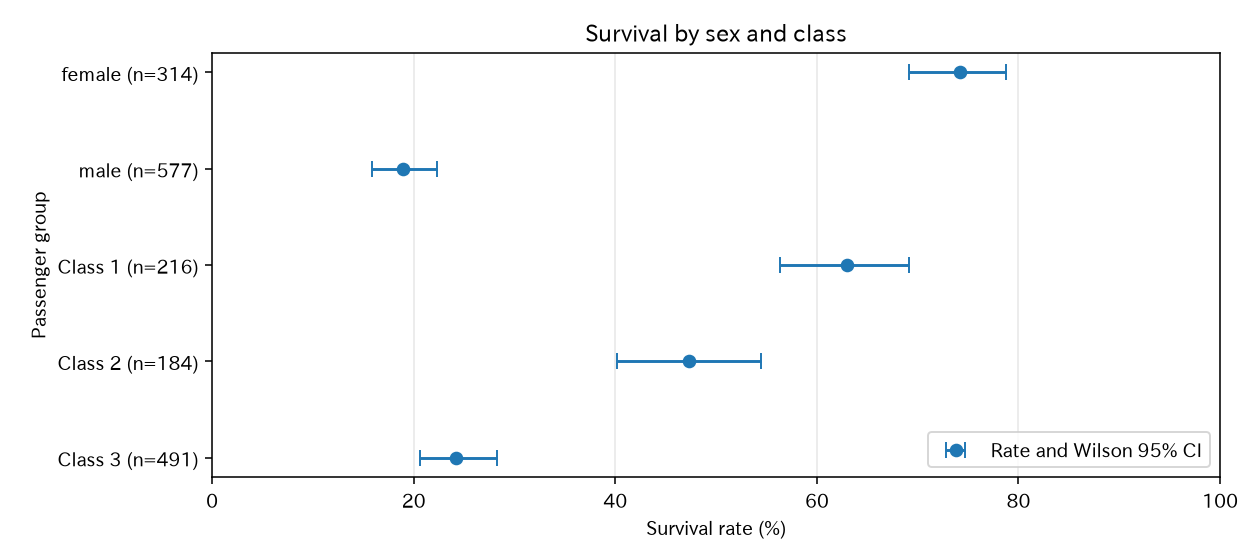

{
  "図1": {
    "title": "Survival by sex and class",
    "xlabel": "Survival rate (%)",
    "ylabel": "Passenger group",
    "legend": "Rate and Wilson 95% CI",
    "missing_glyphs": [],
    "denominator": "各群の全乗客n",
    "x_limits": [
      0,
      100
    ]
  },
  "PNG_bytes": 42373,
  "captured_warnings": []
}

In [10]:
import matplotlib.pyplot as plt
import warnings, re
from ai_data_scientist import visualization
with recorded_cell('chart-primary','図1：主要群の率と区間'):
    # render_chartは日本語フォントを初期化する。画像MIMEはbuild_image_outputで作成する。
    chart_ready = pd.DataFrame({'Group':['女性','男性'],'Survival_pct':[initial_metrics['女性生存率_pct'],initial_metrics['男性生存率_pct']]})
    with warnings.catch_warnings(record=True) as warning_log:
        warnings.simplefilter('always')
        font_preview = visualization.render_chart(chart_ready,kind='bar',x='Group',y='Survival_pct',
                     title='性別の生存率',xlabel='記録された性別',ylabel='生存率 (%)')
        major = pd.concat([rate_tables['Sex'].rename(columns={'Sex':'Group'}),
                           rate_tables['Pclass'].assign(Group=lambda x:'Class '+x.Pclass.astype(str))],ignore_index=True)
        labels = [f'{r.Group} (n={r.n})' for r in major.itertuples()]
        fig,ax = plt.subplots(figsize=(9,4))
        ax.errorbar(100*major.rate,np.arange(len(major)),
                    xerr=np.vstack([100*(major.rate-major.ci_low),100*(major.ci_high-major.rate)]),fmt='o',capsize=4,label='Rate and Wilson 95% CI')
        ax.set(yticks=np.arange(len(major)),yticklabels=labels,xlim=(0,100),xlabel='Survival rate (%)',ylabel='Passenger group',title='Survival by sex and class')
        ax.invert_yaxis(); ax.grid(axis='x',alpha=.3); ax.legend(loc='lower right'); fig.tight_layout()
        buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=140); plt.close(fig)
        image_bytes=buffer.getvalue()
    glyphs = sorted(set(int(m.group(1)) for w in warning_log for m in [re.search(r'Glyph (\d+)',str(w.message))] if m))
    meta={'title':'Survival by sex and class','xlabel':'Survival rate (%)','ylabel':'Passenger group','legend':'Rate and Wilson 95% CI','missing_glyphs':glyphs,'denominator':'各群の全乗客n','x_limits':[0,100]}
    write_notebook(lambda nb: next(c for c in nb.cells if c.id=='chart-primary').metadata.update({'chart':meta}), '図1監査メタデータ')
    display(visualization.build_image_output(image_bytes).data,raw=True)
    emit({'図1':meta,'PNG_bytes':len(image_bytes),'captured_warnings':[str(w.message) for w in warning_log]})


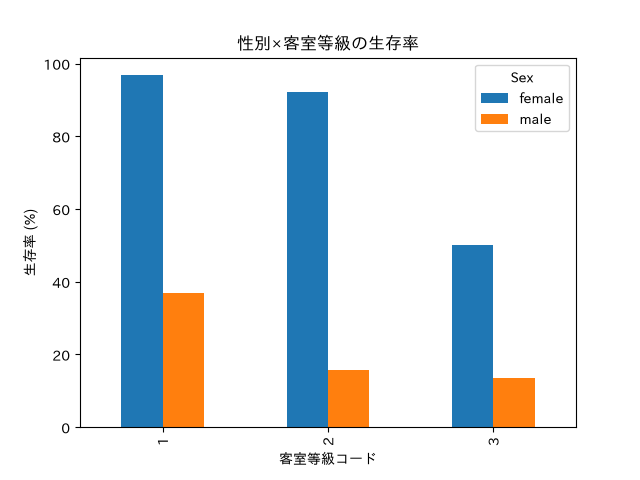

{
  "図2": {
    "title": "性別×客室等級の生存率",
    "xlabel": "客室等級コード",
    "ylabel": "生存率 (%)",
    "legend": [
      "female",
      "male"
    ],
    "missing_glyphs": [],
    "note": "各棒のnと95%区間はsex_class比較表を参照。"
  },
  "PNG_bytes": 18836,
  "captured_warnings": []
}

In [11]:
with recorded_cell('chart-sex-class','図2：性別×等級'):
    grouped_chart = sex_class.pivot(index='Pclass',columns='Sex',values='rate').mul(100).reset_index()
    with warnings.catch_warnings(record=True) as warning_log:
        warnings.simplefilter('always')
        png=visualization.render_chart(grouped_chart,kind='bar',x='Pclass',title='性別×客室等級の生存率',xlabel='客室等級コード',ylabel='生存率 (%)')
    glyphs=sorted(set(int(m.group(1)) for w in warning_log for m in [re.search(r'Glyph (\d+)',str(w.message))] if m))
    meta={'title':'性別×客室等級の生存率','xlabel':'客室等級コード','ylabel':'生存率 (%)','legend':['female','male'],'missing_glyphs':glyphs,'note':'各棒のnと95%区間はsex_class比較表を参照。'}
    write_notebook(lambda nb: next(c for c in nb.cells if c.id=='chart-sex-class').metadata.update({'chart':meta}),'図2監査メタデータ')
    display(visualization.build_image_output(png).data,raw=True)
    emit({'図2':meta,'PNG_bytes':len(png),'captured_warnings':[str(w.message) for w in warning_log]})


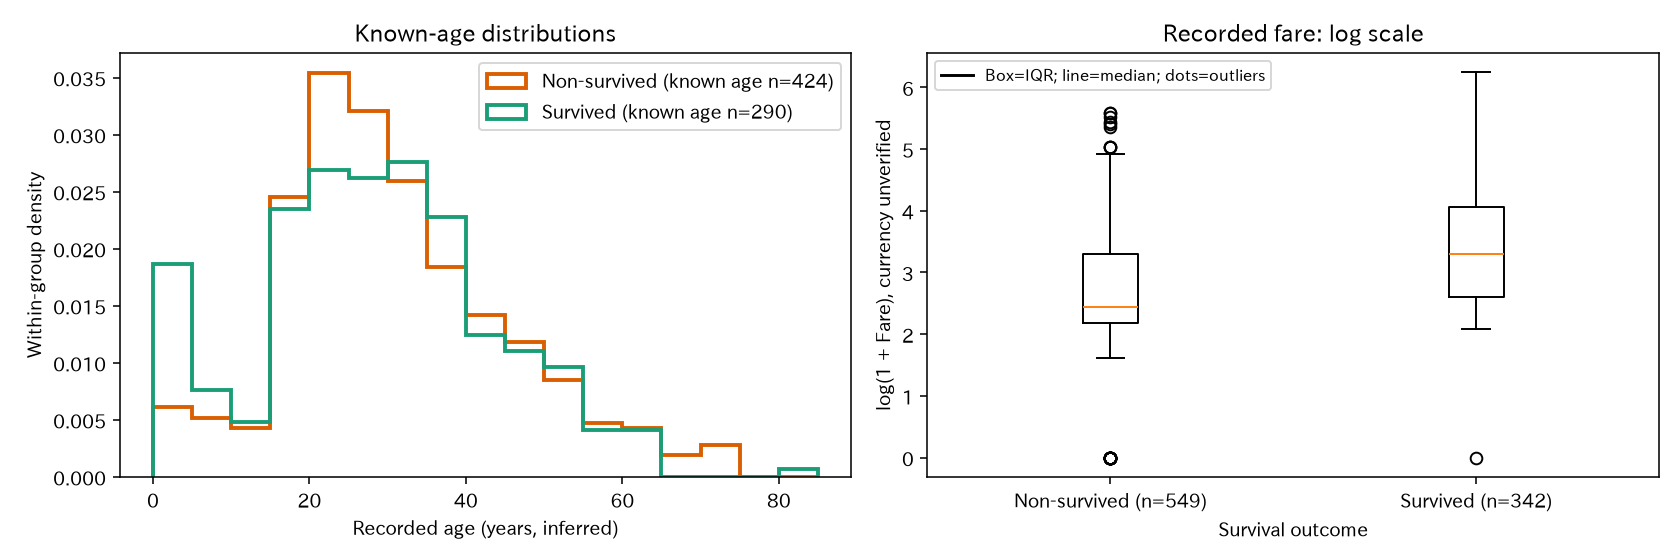

{
  "図3": {
    "title": [
      "Known-age distributions",
      "Recorded fare: log scale"
    ],
    "xlabel": [
      "Recorded age",
      "Survival outcome"
    ],
    "ylabel": [
      "Within-group density",
      "log(1+Fare)"
    ],
    "legend": [
      "Non-survived",
      "Survived",
      "Box=IQR; line=median; dots=outliers"
    ],
    "missing_glyphs": [],
    "age_missing": 177,
    "fare_units": "unknown",
    "shared_age_bins": [
      0,
      5,
      10,
      15,
      20,
      25,
      30,
      35,
      40,
      45,
      50,
      55,
      60,
      65,
      70,
      75,
      80,
      85
    ]
  },
  "PNG_bytes": 74981,
  "captured_warnings": []
}

In [12]:
with recorded_cell('chart-distributions','図3：年齢と運賃の分布'):
    with warnings.catch_warnings(record=True) as warning_log:
        warnings.simplefilter('always')
        fig,axes=plt.subplots(1,2,figsize=(12,4))
        colors=['#d95f02','#1b9e77']
        for outcome,label,color in zip([0,1],['Non-survived','Survived'],colors):
            age_values=df.loc[df.Survived==outcome,'Age'].dropna()
            axes[0].hist(age_values,bins=np.arange(0,86,5),density=True,histtype='step',linewidth=2,color=color,label=f'{label} (known age n={len(age_values)})')
        axes[0].set(title='Known-age distributions',xlabel='Recorded age (years, inferred)',ylabel='Within-group density')
        axes[0].legend()
        fare_values=[np.log1p(df.loc[df.Survived==s,'Fare']) for s in [0,1]]
        axes[1].boxplot(fare_values,tick_labels=['Non-survived (n=549)','Survived (n=342)'],showfliers=True)
        axes[1].set(title='Recorded fare: log scale',xlabel='Survival outcome',ylabel='log(1 + Fare), currency unverified')
        axes[1].plot([],[],color='black',label='Box=IQR; line=median; dots=outliers'); axes[1].legend(fontsize=8)
        fig.tight_layout(); buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=140); plt.close(fig)
    glyphs=sorted(set(int(m.group(1)) for w in warning_log for m in [re.search(r'Glyph (\d+)',str(w.message))] if m))
    meta={'title':['Known-age distributions','Recorded fare: log scale'],'xlabel':['Recorded age','Survival outcome'],
          'ylabel':['Within-group density','log(1+Fare)'],'legend':['Non-survived','Survived','Box=IQR; line=median; dots=outliers'],'missing_glyphs':glyphs,
          'age_missing':177,'fare_units':'unknown','shared_age_bins':list(range(0,86,5))}
    write_notebook(lambda nb: next(c for c in nb.cells if c.id=='chart-distributions').metadata.update({'chart':meta}),'図3監査メタデータ')
    display(visualization.build_image_output(buffer.getvalue()).data,raw=True)
    emit({'図3':meta,'PNG_bytes':len(buffer.getvalue()),'captured_warnings':[str(w.message) for w in warning_log]})


## 反復依頼履歴

### 反復1：年齢欠損と層別の頑健性

追加依頼文（原文）：
> 年齢が約20%欠損しているので、「子どもほど生存しやすい」と「女性の生存率が高い」という結論が年齢欠損や等級構成に依存しないか調べてください。年齢の観測・欠損を分け、性別×等級で比較し、子どもの閾値と欠損の扱いを変えた感度分析を行ってください。極端な欠損割当てはストレステストと明記し、結論をどこまで支持できるか説明してください。

選定理由：初回の年齢中央値は両群28歳だが低年齢の密度と率が異なる。177人の欠損の選択性が結論を変え得るため、平均だけの説明を補う。性別差を等級調整後に比較することは主要結論に直接関係する。

In [13]:
from ai_data_scientist import sensitivity
with recorded_cell('iteration-1','反復1：年齢欠損・層別感度分析'):
    df['AgeMissing'] = df.Age.isna()
    display(rates(df,['AgeMissing']).round(6))
    missing_structure = df.groupby(['Sex','Pclass'],observed=True).agg(n=('AgeMissing','size'),age_missing=('AgeMissing','sum'),age_missing_rate=('AgeMissing','mean'))
    display(missing_structure.round(6))
    display(rates(df,['AgeMissing','Sex','Pclass']).round(6))
    def sex_gap(subset, adjustment):
        data = df if subset=='all' else df.loc[df.Age.isna() if subset=='age_missing' else df.Age.notna()]
        if adjustment=='raw':
            return data.loc[data.Sex=='female','Survived'].mean()-data.loc[data.Sex=='male','Survived'].mean()
        table = data.groupby(['Pclass','Sex'],observed=True).Survived.mean().unstack()
        if table[['female','male']].isna().any().any():
            raise RuntimeError('等級標準化に必要な性別群がありません。')
        weights = data.Pclass.value_counts(normalize=True).sort_index()
        return float(((table.female-table.male)*weights).sum())
    sex_plan=sensitivity.SensitivityPlan(parameter_grid={'subset':['all','known_age','age_missing'],'adjustment':['raw','class_standardized']},max_runs=6)
    sex_sensitivity=sensitivity.run_sensitivity(sex_plan,sex_gap,stability_tolerance=.2)
    emit({'sex_sensitivity':asdict(sex_sensitivity),'tolerance':.2,'note':'各subsetの全体等級構成で直接標準化。subset間で目標母集団は異なる。'})
    def child_gap(threshold, missing):
        data=df.copy()
        if missing=='observed':
            data=data.dropna(subset=['Age'])
        else:
            medians=data.groupby(['Sex','Pclass'],observed=True).Age.transform('median')
            data['Age']=data.Age.fillna(medians)
        child=data.Age < threshold
        return float(data.loc[child,'Survived'].mean()-data.loc[~child,'Survived'].mean())
    child_plan=sensitivity.SensitivityPlan(parameter_grid={'threshold':[12,16,18],'missing':['observed','sex_class_median']},max_runs=6)
    child_sensitivity=sensitivity.run_sensitivity(child_plan,child_gap,stability_tolerance=.2)
    emit({'child_sensitivity':asdict(child_sensitivity),'tolerance':.2,'note':'中央値補完はMNARを解決せず、不確実性も伝播しない。閾値は12歳未満/16歳未満/18歳未満。'})
    stress=[]
    for allocation in ['all_missing_adult','all_missing_child']:
        child=(df.Age<12) | (df.Age.isna() if allocation=='all_missing_child' else False)
        stress.append({'allocation':allocation,'child_n':int(child.sum()),'child_rate':float(df.loc[child,'Survived'].mean()),
                       'adult_rate':float(df.loc[~child,'Survived'].mean()),'gap':float(df.loc[child,'Survived'].mean()-df.loc[~child,'Survived'].mean())})
    emit({'extreme_missing_allocation_stress':stress,'plausible_model':False})
    child_strata=df.loc[df.Age.notna()].copy()
    child_strata['Child12']=child_strata.Age<12
    display(rates(child_strata,['Sex','Pclass','Child12']).round(6))
    iteration1_metrics={'sex_gap_min':min(r.value for r in sex_sensitivity.results), 'sex_gap_max':max(r.value for r in sex_sensitivity.results),
                        'sex_stable':sex_sensitivity.stable,'sex_max_relative_deviation':sex_sensitivity.max_relative_deviation,
                        'child_gap_min':min(r.value for r in child_sensitivity.results),'child_gap_max':max(r.value for r in child_sensitivity.results),
                        'child_stable':child_sensitivity.stable,'child_max_relative_deviation':child_sensitivity.max_relative_deviation,
                        'missing_age_survival':float(df.loc[df.AgeMissing,'Survived'].mean()),
                        'known_age_survival':float(df.loc[~df.AgeMissing,'Survived'].mean())}
    emit('ITERATION1_METRICS='+json.dumps(iteration1_metrics,ensure_ascii=False,sort_keys=True))


,AgeMissing,n,survivors,rate,ci_low,ci_high
0,False,714,290,0.406162,0.370734,0.442595
1,True,177,52,0.293785,0.231634,0.364697


n  age_missing  age_missing_rate
Sex    Pclass                                    
female 1        94            9          0.095745
       2        76            2          0.026316
       3       144           42          0.291667
male   1       122           21          0.172131
       2       108            9          0.083333
       3       347           94          0.270893

,AgeMissing,Sex,Pclass,n,survivors,rate,ci_low,ci_high
0,False,female,1,85,82,0.964706,0.901300,0.987925
1,False,female,2,74,68,0.918919,0.834181,0.962310
2,False,female,3,102,47,0.460784,0.367235,0.557180
3,False,male,1,101,40,0.396040,0.306154,0.493543
4,False,male,2,99,15,0.151515,0.094023,0.235041
5,False,male,3,253,38,0.150198,0.111425,0.199434
6,True,female,1,9,9,1.000000,0.700855,1.000000
7,True,female,2,2,2,1.000000,0.342380,1.000000
8,True,female,3,42,25,0.595238,0.444943,0.729571
9,True,male,1,21,5,0.238095,0.106280,0.450912


{
  "sex_sensitivity": {
    "results": [
      {
        "specification": {
          "subset": "all",
          "adjustment": "raw"
        },
        "value": 0.5531300709799203
      },
      {
        "specification": {
          "subset": "all",
          "adjustment": "class_standardized"
        },
        "value": 0.5038615603952583
      },
      {
        "specification": {
          "subset": "known_age",
          "adjustment": "raw"
        },
        "value": 0.5494912587856182
      },
      {
        "specification": {
          "subset": "known_age",
          "adjustment": "class_standardized"
        },
        "value": 0.4885028750863409
      },
      {
        "specification": {
          "subset": "age_missing",
          "adjustment": "raw"
        },
        "value": 0.5502130249543518
      },
      {
        "specification": {
          "subset": "age_missing",
          "adjustment": "class_standardized"
        },
        "value": 0.5612644224256197
      

{
  "child_sensitivity": {
    "results": [
      {
        "specification": {
          "threshold": 12,
          "missing": "observed"
        },
        "value": 0.18498452012383898
      },
      {
        "specification": {
          "threshold": 12,
          "missing": "sex_class_median"
        },
        "value": 0.205364162676006
      },
      {
        "specification": {
          "threshold": 16,
          "missing": "observed"
        },
        "value": 0.2084280067973956
      },
      {
        "specification": {
          "threshold": 16,
          "missing": "sex_class_median"
        },
        "value": 0.22773768340689493
      },
      {
        "specification": {
          "threshold": 18,
          "missing": "observed"
        },
        "value": 0.158791394872852
      },
      {
        "specification": {
          "threshold": 18,
          "missing": "sex_class_median"
        },
        "value": 0.1786404895693518
      }
    ],
    "baseline_value": 0.18

{
  "extreme_missing_allocation_stress": [
    {
      "allocation": "all_missing_adult",
      "child_n": 68,
      "child_rate": 0.5735294117647058,
      "adult_rate": 0.36816524908869985,
      "gap": 0.205364162676006
    },
    {
      "allocation": "all_missing_child",
      "child_n": 245,
      "child_rate": 0.37142857142857144,
      "adult_rate": 0.38854489164086686,
      "gap": -0.01711632021229542
    }
  ],
  "plausible_model": false
}

,Sex,Pclass,Child12,n,survivors,rate,ci_low,ci_high
0,female,1,False,84,82,0.976190,0.917286,0.993446
1,female,1,True,1,0,0.000000,0.000000,0.793451
2,female,2,False,66,60,0.909091,0.815513,0.957667
3,female,2,True,8,8,1.000000,0.675592,1.000000
4,female,3,False,79,36,0.455696,0.350485,0.565017
5,female,3,True,23,11,0.478261,0.292372,0.670373
6,male,1,False,98,37,0.377551,0.287905,0.476434
7,male,1,True,3,3,1.000000,0.438503,1.000000
8,male,2,False,90,6,0.066667,0.030910,0.137901
9,male,2,True,9,9,1.000000,0.700855,1.000000


ITERATION1_METRICS={"child_gap_max": 0.22773768340689493, "child_gap_min": 0.158791394872852, "child_max_relative_deviation": 0.23111751866823554, "child_stable": false, "known_age_survival": 0.4061624649859944, "missing_age_survival": 0.2937853107344633, "sex_gap_max": 0.5612644224256197, "sex_gap_min": 0.4885028750863409, "sex_max_relative_deviation": 0.11683905700351174, "sex_stable": true}

In [14]:
with recorded_cell('iteration1-report','反復1結果と根拠'):
    text=('反復1結果：女性−男性の生存率差は年齢観測/欠損と等級標準化を変えて48.9–56.1ポイントで、'
          '事前の相対変動20%基準ではstable=True、max_relative_deviation=0.11683905700351174。主要な性別差はこの範囲では安定。'
          '一方、子ども対それ以上の年齢群の差は閾値12/16/18歳と欠損処理で15.9–22.8ポイント、stable=False、max_relative_deviation=0.23111751866823554。'
          '方向は正でも大きさは安定と呼べない。年齢欠損群29.4%対観測群40.6%で、欠損は3等に多く完全症例は選択された部分集団。'
          '欠損全員を子どもとする非現実的ストレスでは差が−1.7ポイントになり、欠損年齢が不明なまま全員に普遍化はできない。'
          '男性の12歳未満は各等級で比較群より高いが、女性1等の子どもは1人で0%、小標本から例外や機序を説明しない。'
          '根拠：iteration-1の生存率表、欠損構成、6+6仕様と極端割当て。残る限界：詳細定義、MNAR欠損、共有券依存、層内の小標本。'
          '次に運賃や家族・記録項目の交絡を検討する価値がある。')
    save_insight('insight-iteration1','iteration1-report',text,'iteration-1',r'ITERATION1_METRICS=(.+)')
    emit({'選定理由':'主要結論の年齢欠損・等級交絡に直接対応','結果根拠':iteration1_metrics,'次の未解決点':'運賃・家族・港・客室記録の追加的関連'})


{
  "選定理由": "主要結論の年齢欠損・等級交絡に直接対応",
  "結果根拠": {
    "sex_gap_min": 0.4885028750863409,
    "sex_gap_max": 0.5612644224256197,
    "sex_stable": true,
    "sex_max_relative_deviation": 0.11683905700351174,
    "child_gap_min": 0.158791394872852,
    "child_gap_max": 0.22773768340689493,
    "child_stable": false,
    "child_max_relative_deviation": 0.23111751866823554,
    "missing_age_survival": 0.2937853107344633,
    "known_age_survival": 0.4061624649859944
  },
  "次の未解決点": "運賃・家族・港・客室記録の追加的関連"
}

### 反復2：運賃・家族・記録項目の交絡

追加依頼文（原文）：
> 生存者の運賃が高く、2～4人の家族群、C港、客室記録ありの生存率も高いですが、性別・客室等級・年齢の構成の違いで説明される可能性を調べてください。層別表と説明用のロジスティックモデルを使い、年齢欠損処理と高額運賃の扱いを変えてください。共有Ticketで標準誤差を調整し、因果効果と誤解されないように、どの関連が仕様依存かを示してください。

選定理由：反復1は性別差を支持したが、運賃や家族の初回差が独立した効果とは判断できない。客室欠損と港の粗差も等級・性別の代理かもしれない。モデルは予測性能の最適化ではなく交絡感度の記述に限定する。年齢中央値補完/完全症例、運賃そのまま/99パーセンタイル上限の4仕様を事前に固定する。

In [15]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
with recorded_cell('iteration-2','反復2：交絡・共有券調整'):
    display(rates(df,['Sex','Pclass','FamilyGroup']).round(6))
    display(rates(df,['Sex','Pclass','CabinRecorded']).round(6))
    port_structure=pd.crosstab([df.Sex,df.Pclass],df.Port)
    display(port_structure)
    port_rates=rates(df,['Sex','Pclass','Port'])
    display(port_rates.round(6))
    fare_strata=df.groupby(['Sex','Pclass','Survived'],observed=True).Fare.agg(['size','median','mean'])
    display(fare_strata.round(4))
    # C/Sを同じ性別×等級構成に標準化。Qは複数層でnが極少なので調整比較を保留。
    cs=df[df.Port.isin(['C','S'])]
    counts=cs.groupby(['Sex','Pclass','Port'],observed=True).size().unstack('Port')
    if counts.isna().any().any() or (counts<5).any().any():
        raise RuntimeError('C/S直接標準化の層別最低n>=5を満たしません。')
    weights=cs.groupby(['Sex','Pclass'],observed=True).size()/len(cs)
    rate_by_port=cs.groupby(['Sex','Pclass','Port'],observed=True).Survived.mean().unstack('Port')
    port_raw_gap=float(cs.loc[cs.Port=='C','Survived'].mean()-cs.loc[cs.Port=='S','Survived'].mean())
    port_adjusted_gap=float(((rate_by_port.C-rate_by_port.S)*weights).sum())
    model_results={}
    model_tables=[]
    def fit_explanation(age_method, fare_method):
        data=df[df.Embarked.notna()].copy()
        if age_method=='complete':
            data=data[data.Age.notna()].copy()
            data['AgeFilled']=data.Age
        else:
            data['AgeFilled']=data.Age.fillna(data.groupby(['Sex','Pclass'],observed=True).Age.transform('median'))
        data['AgeCentered']=(data.AgeFilled-30)/10
        fare=data.Fare.clip(upper=df.Fare.quantile(.99)) if fare_method=='cap99' else data.Fare
        data['LogFare']=np.log1p(fare)
        data['AgeMissing']=data.Age.isna().astype(int)
        for column in ['Sex','FamilyGroup','Port','CabinRecorded']:
            data[column]=data[column].astype(object)
        formula="Survived ~ C(Sex, Treatment(reference='male')) * C(Pclass, Treatment(reference=3)) + AgeCentered + I(AgeCentered ** 2) + LogFare + C(FamilyGroup, Treatment(reference='Alone')) + C(Port, Treatment(reference='S')) + C(CabinRecorded, Treatment(reference='Missing'))"
        if age_method=='median':
            formula+=' + AgeMissing'
        model=smf.glm(formula=formula,data=data,family=sm.families.Binomial())
        fit=model.fit(cov_type='cluster',cov_kwds={'groups':data.Ticket})
        if not fit.converged or not np.isfinite(fit.params).all():
            raise RuntimeError('説明モデルが収束/有限値条件を満たしません。')
        covariate_rank=int(np.linalg.matrix_rank(fit.model.exog))
        if covariate_rank != fit.model.exog.shape[1]:
            raise RuntimeError('説明モデルのデザイン行列がフルランクではありません。')
        intervals=fit.conf_int()
        table=pd.DataFrame({'coefficient':fit.params,'OR':np.exp(fit.params),
                            'OR_low95_ticket_cluster':np.exp(intervals[0]),'OR_high95_ticket_cluster':np.exp(intervals[1])})
        female=data.copy(); female['Sex']='female'
        male=data.copy(); male['Sex']='male'
        predictive_contrast=float((fit.predict(female)-fit.predict(male)).mean())
        model_results[(age_method,fare_method)]={'fit':fit,'data':data,'table':table,'contrast':predictive_contrast}
        model_tables.append({'age':age_method,'fare':fare_method,'n':len(data),'ticket_clusters':data.Ticket.nunique(),
                             'rank':covariate_rank,'parameters':fit.model.exog.shape[1],
                             'female_minus_male_standardized_prediction':predictive_contrast,
                             'LogFare_OR':float(table.loc['LogFare','OR']),
                             'LogFare_OR_low95':float(table.loc['LogFare','OR_low95_ticket_cluster']),
                             'LogFare_OR_high95':float(table.loc['LogFare','OR_high95_ticket_cluster'])})
        return predictive_contrast
    explanatory_plan=sensitivity.SensitivityPlan(parameter_grid={'age_method':['median','complete'],'fare_method':['raw','cap99']},max_runs=4)
    model_sensitivity=sensitivity.run_sensitivity(explanatory_plan,fit_explanation,stability_tolerance=.2)
    emit({'model_specifications':model_tables,'sex_model_sensitivity':asdict(model_sensitivity),
          'port_C_minus_S_raw':port_raw_gap,'port_C_minus_S_sex_class_standardized':port_adjusted_gap,
          'port_Q_adjustment':'層の標本が小さすぎるので全体標準化を推奨しない。'})
    for key,result in model_results.items():
        emit('共有Ticketクラスタ95%区間、説明モデル: '+str(key))
        display(result['table'].round(6))
    iteration2_metrics={'port_raw_gap':port_raw_gap,'port_adjusted_gap':port_adjusted_gap,
                        'sex_model_gap_min':min(r.value for r in model_sensitivity.results),
                        'sex_model_gap_max':max(r.value for r in model_sensitivity.results),
                        'sex_model_stable':model_sensitivity.stable,
                        'sex_model_max_relative_deviation':model_sensitivity.max_relative_deviation,
                        'LogFare_OR_range':[min(t['LogFare_OR'] for t in model_tables),max(t['LogFare_OR'] for t in model_tables)]}
    emit('ITERATION2_METRICS='+json.dumps(iteration2_metrics,ensure_ascii=False,sort_keys=True))


,Sex,Pclass,FamilyGroup,n,survivors,rate,ci_low,ci_high
0,female,1,2-4,56,54,0.964286,0.878812,0.990151
1,female,1,5+,4,4,1.000000,0.510109,1.000000
2,female,1,Alone,34,33,0.970588,0.850844,0.994789
3,female,2,2-4,42,39,0.928571,0.809906,0.975410
4,female,2,5+,2,2,1.000000,0.342380,1.000000
5,female,2,Alone,32,29,0.906250,0.757818,0.967598
6,female,3,2-4,57,32,0.561404,0.432780,0.682273
7,female,3,5+,27,3,0.111111,0.038520,0.280578
8,female,3,Alone,60,37,0.616667,0.490176,0.729117
9,male,1,2-4,45,20,0.444444,0.309389,0.588239


,Sex,Pclass,CabinRecorded,n,survivors,rate,ci_low,ci_high
0,female,1,Missing,13,13,1.000000,0.771905,1.000000
1,female,1,Recorded,81,78,0.962963,0.896677,0.987325
2,female,2,Missing,66,61,0.924242,0.834608,0.967208
3,female,2,Recorded,10,9,0.900000,0.595850,0.982124
4,female,3,Missing,138,68,0.492754,0.410674,0.575226
5,female,3,Recorded,6,4,0.666667,0.299993,0.903229
6,male,1,Missing,27,6,0.222222,0.106072,0.407569
7,male,1,Recorded,95,39,0.410526,0.316962,0.511046
8,male,2,Missing,102,13,0.127451,0.076018,0.205927
9,male,2,Recorded,6,4,0.666667,0.299993,0.903229


Port            C  Missing   Q    S
Sex    Pclass                      
female 1       43        2   1   48
       2        7        0   2   67
       3       23        0  33   88
male   1       42        0   1   79
       2       10        0   1   97
       3       43        0  39  265

,Sex,Pclass,Port,n,survivors,rate,ci_low,ci_high
0,female,1,C,43,42,0.976744,0.879410,0.995883
1,female,1,Missing,2,2,1.000000,0.342380,1.000000
2,female,1,Q,1,1,1.000000,0.206549,1.000000
3,female,1,S,48,46,0.958333,0.860243,0.988498
4,female,2,C,7,7,1.000000,0.645670,1.000000
5,female,2,Q,2,2,1.000000,0.342380,1.000000
6,female,2,S,67,61,0.910448,0.818072,0.958309
7,female,3,C,23,15,0.652174,0.448903,0.811887
8,female,3,Q,33,24,0.727273,0.557824,0.849326
9,female,3,S,88,33,0.375000,0.281079,0.479378


size    median      mean
Sex    Pclass Survived                          
female 1      0            3  151.5500  110.6042
              1           91   82.1708  105.9782
       2      0            6   17.0000   18.2500
              1           70   23.0000   22.2890
       3      0           72   14.4792   19.7731
              1           72    9.4688   12.4645
male   1      0           77   42.4000   62.8949
              1           45   35.5000   74.6373
       2      0           91   13.0000   19.4890
              1           17   18.7500   21.0951
       3      0          300    7.8958   12.2045
              1           47    8.0500   15.5797

...

共有Ticketクラスタ95%区間、説明モデル: ('complete', 'raw')

,coefficient,OR,OR_low95_ticket_cluster,OR_high95_ticket_cluster
Intercept,-2.382010,0.092365,0.029588,0.288335
"C(Sex, Treatment(reference='male'))[T.female]",1.539301,4.661331,2.574585,8.439422
"C(Pclass, Treatment(reference=3))[T.1]",1.021695,2.777899,0.724538,10.650544
"C(Pclass, Treatment(reference=3))[T.2]",-0.229199,0.795171,0.364512,1.734636
"C(FamilyGroup, Treatment(reference='Alone'))[T.2-4]",-0.045162,0.955842,0.537166,1.700840
"C(FamilyGroup, Treatment(reference='Alone'))[T.5+]",-2.351366,0.095239,0.019428,0.466887
"C(Port, Treatment(reference='S'))[T.C]",0.306232,1.358298,0.737023,2.503275
"C(Port, Treatment(reference='S'))[T.Q]",-0.120675,0.886322,0.337527,2.327418
"C(CabinRecorded, Treatment(reference='Missing'))[T.Recorded]",0.623079,1.864661,0.711215,4.888760
"C(Sex, Treatment(reference='male'))[T.female]:C(Pclass, Treatment(reference=3))[T.1]",2.112605,8.269753,1.412676,48.410828


共有Ticketクラスタ95%区間、説明モデル: ('complete', 'cap99')

,coefficient,OR,OR_low95_ticket_cluster,OR_high95_ticket_cluster
Intercept,-2.322931,0.097986,0.030616,0.313601
"C(Sex, Treatment(reference='male'))[T.female]",1.538988,4.659873,2.572254,8.441786
"C(Pclass, Treatment(reference=3))[T.1]",1.061309,2.890151,0.747219,11.178743
"C(Pclass, Treatment(reference=3))[T.2]",-0.213035,0.808128,0.368100,1.774166
"C(FamilyGroup, Treatment(reference='Alone'))[T.2-4]",-0.029055,0.971363,0.541626,1.742063
"C(FamilyGroup, Treatment(reference='Alone'))[T.5+]",-2.315515,0.098715,0.020027,0.486579
"C(Port, Treatment(reference='S'))[T.C]",0.314346,1.369363,0.743747,2.521226
"C(Port, Treatment(reference='S'))[T.Q]",-0.119696,0.887191,0.337746,2.330470
"C(CabinRecorded, Treatment(reference='Missing'))[T.Recorded]",0.624541,1.867389,0.713699,4.886007
"C(Sex, Treatment(reference='male'))[T.female]:C(Pclass, Treatment(reference=3))[T.1]",2.124218,8.366353,1.426740,49.060005


ITERATION2_METRICS={"LogFare_OR_range": [1.1284855011409989, 1.2972832765791393], "port_adjusted_gap": 0.10113695349172645, "port_raw_gap": 0.21661490683229817, "sex_model_gap_max": 0.46576800576985666, "sex_model_gap_min": 0.45910636552962264, "sex_model_max_relative_deviation": 0.014119647955741423, "sex_model_stable": true}

In [16]:
with recorded_cell('iteration2-report','反復2結果と根拠'):
    text=('反復2結果：性別×等級の交互作用、年齢二次項、家族代理群、港、客室記録、log(1+運賃)を含む説明GLMで、'
          '性別を置き換えた予測値の平均差は45.9–46.6ポイント。4仕様のstable=True、max_relative_deviation=0.014119647955741423。'
          'これは共変量分布上の記述的な予測対比で、性別の因果効果ではない。'
          '運賃のORはlog(1+Fare)が1増加するごとに1.13–1.30で、共有Ticketクラスタ95%区間は全仕様で1を含む。'
          '生存群の高い粗運賃から、支払いを増やせば生存しやすいとは結論できない。'
          'C−S港の粗差21.7ポイントは共通の性別×等級構成で10.1ポイントに縮む。Q港は層別に極小標本で全体調整の解釈を保留。'
          '2–4人家族群の粗い優位と客室記録ありの粗差も、調整GLMでは明確な追加的関連と呼べず、大人数家族の低さは共有券依存に注意が必要。'
          '根拠：iteration-2の層別表、C/S直接標準化、4モデル係数/クラスタ区間、ITERATION2_METRICS。'
          'モデルでは乗船港欠損2人を除外（全行比較は891人を維持）、中央値補完889人/完全症例712人。'
          '残る限界：モデル形の制約、単一補完、層内支持不足、港・客室記録の測定/選択バイアス、共有券以外の依存。'
          '点推定が安定でも区間の校正や因果識別を保証しない。最後にクラスタ再標本化で主要差と家族差を検証する。')
    save_insight('insight-iteration2','iteration2-report',text,'iteration-2',r'ITERATION2_METRICS=(.+)')
    emit({'選定理由':'粗い運賃・家族・港・客室記録の差の交絡を検討','結果根拠':iteration2_metrics,
          '次の未解決点':'共有券依存と大人数家族が少数の券に集中する影響'})


{
  "選定理由": "粗い運賃・家族・港・客室記録の差の交絡を検討",
  "結果根拠": {
    "port_raw_gap": 0.21661490683229817,
    "port_adjusted_gap": 0.10113695349172645,
    "sex_model_gap_min": 0.45910636552962264,
    "sex_model_gap_max": 0.46576800576985666,
    "sex_model_stable": true,
    "sex_model_max_relative_deviation": 0.014119647955741423,
    "LogFare_OR_range": [
      1.1284855011409989,
      1.2972832765791393
    ]
  },
  "次の未解決点": "共有券依存と大人数家族が少数の券に集中する影響"
}

### 反復3：共有Ticket依存と少数クラスタの影響

追加依頼文（原文）：
> 共有Ticketで乗客の生存結果が依存する可能性があるので、性別差と家族人数別の生存率差について、乗客単位とTicket単位のブートストラップ区間を比較してください。少数のTicketが大人数家族の結論を支配していないか、1 Ticketずつ除外したときの変化も調べてください。再標本化の単位、反復数、乱数seedを固定し、点推定の安定と母集団への一般化を分けて説明してください。

選定理由：反復2はクラスタ標準誤差を使用したが、最初のWilson区間は独立乗客近似のまま。家族5人以上の62人は複数人が同じTicketにまとまる可能性があり、主要性別差と二次的な家族差の区間・影響度を分けて評価する価値がある。2000反復、seed=20261002。Ticketは真の救命艇・全同行集団ではなく利用可能な依存性代理である。

In [17]:
with recorded_cell('iteration-3','反復3：Ticket再標本化・影響度'):
    B=2000; SEED=20261002
    categories={'female':df.Sex=='female','male':df.Sex=='male',
                'Alone':df.FamilyGroup=='Alone','2-4':df.FamilyGroup=='2-4','5+':df.FamilyGroup=='5+'}
    group_names=list(categories)
    counts_matrix=np.column_stack([categories[c].to_numpy(dtype=int) for c in group_names])
    survivors_matrix=counts_matrix*df.Survived.to_numpy()[:,None]
    _,ticket_index=np.unique(df.Ticket.astype(str).to_numpy(),return_inverse=True)
    T=int(ticket_index.max()+1)
    ticket_counts=np.zeros((T,len(group_names)),dtype=int)
    ticket_survivors=np.zeros_like(ticket_counts)
    np.add.at(ticket_counts,ticket_index,counts_matrix)
    np.add.at(ticket_survivors,ticket_index,survivors_matrix)
    bootstrap_rows=[]
    bootstrap_samples={}
    rng=np.random.default_rng(SEED)
    for unit,denoms,nums in [('Passenger',counts_matrix,survivors_matrix),('Ticket',ticket_counts,ticket_survivors)]:
        units=len(denoms)
        resample_weights=rng.multinomial(units,np.full(units,1/units),size=B)
        denom_boot=resample_weights@denoms
        nums_boot=resample_weights@nums
        if (denom_boot==0).any():
            raise RuntimeError('再標本化で群の分母0を検出。仕様を再検討してください。')
        rates_boot=nums_boot/denom_boot
        contrasts={'female_minus_male':rates_boot[:,0]-rates_boot[:,1],
                   'family_2to4_minus_alone':rates_boot[:,3]-rates_boot[:,2],
                   'family_5plus_minus_alone':rates_boot[:,4]-rates_boot[:,2]}
        actual=nums.sum(axis=0)/denoms.sum(axis=0)
        points={'female_minus_male':actual[0]-actual[1],'family_2to4_minus_alone':actual[3]-actual[2],
                'family_5plus_minus_alone':actual[4]-actual[2]}
        for contrast,values in contrasts.items():
            low,high=np.quantile(values,[.025,.975])
            bootstrap_rows.append({'unit':unit,'contrast':contrast,'point':float(points[contrast]),
                                   'ci_low':float(low),'ci_high':float(high),'width':float(high-low)})
        bootstrap_samples[unit]=contrasts
    bootstrap_table=pd.DataFrame(bootstrap_rows)
    display(bootstrap_table.round(6))
    total_n=ticket_counts.sum(axis=0); total_s=ticket_survivors.sum(axis=0)
    remaining_n=total_n-ticket_counts
    if (remaining_n==0).any():
        raise RuntimeError('1券除外で分母0になる群があります。')
    leave_rates=(total_s-ticket_survivors)/remaining_n
    leave_contrasts={'female_minus_male':leave_rates[:,0]-leave_rates[:,1],
                     'family_2to4_minus_alone':leave_rates[:,3]-leave_rates[:,2],
                     'family_5plus_minus_alone':leave_rates[:,4]-leave_rates[:,2]}
    leave_rows=[]
    for name,values in leave_contrasts.items():
        point=float(bootstrap_table[bootstrap_table.contrast==name].point.iloc[0])
        leave_rows.append({'contrast':name,'full_point':point,'leave_one_ticket_min':float(values.min()),
                           'leave_one_ticket_max':float(values.max()),'max_absolute_shift':float(np.abs(values-point).max())})
    display(pd.DataFrame(leave_rows).round(6))
    cluster_support={name:{'passengers':int(total_n[i]),'tickets':int((ticket_counts[:,i]>0).sum()),
                           'max_passengers_per_ticket':int(ticket_counts[:,i].max())} for i,name in enumerate(group_names)}
    emit({'B':B,'seed':SEED,'ticket_clusters':T,'cluster_support':cluster_support,
          'method':'等確率で単位を復元抽出、percentile 95%区間。Ticket再標本化では全乗客を一緒に複製、総乗客数は変動。',
          'not_proof':'クラスタが互いに独立という近似。真の家族・救命艇/避難経路の依存を完全には表さない。'})
    iteration3_metrics={'bootstrap':bootstrap_rows,'leave_one_ticket':leave_rows,'support':cluster_support,'B':B,'seed':SEED}
    emit('ITERATION3_METRICS='+json.dumps(iteration3_metrics,ensure_ascii=False,sort_keys=True))


,unit,contrast,point,ci_low,ci_high,width
0,Passenger,female_minus_male,0.553130,0.494266,0.609708,0.115443
1,Passenger,family_2to4_minus_alone,0.275229,0.206416,0.340594,0.134179
2,Passenger,family_5plus_minus_alone,-0.142248,-0.233267,-0.034349,0.198917
3,Ticket,female_minus_male,0.553130,0.485187,0.618835,0.133649
4,Ticket,family_2to4_minus_alone,0.275229,0.202729,0.344434,0.141705
5,Ticket,family_5plus_minus_alone,-0.142248,-0.266918,0.049828,0.316746


,contrast,full_point,leave_one_ticket_min,leave_one_ticket_max,max_absolute_shift
0,female_minus_male,0.553130,0.549802,0.564480,0.011350
1,family_2to4_minus_alone,0.275229,0.269378,0.281237,0.006008
2,family_5plus_minus_alone,-0.142248,-0.182849,-0.121720,0.040601


{
  "B": 2000,
  "seed": 20261002,
  "ticket_clusters": 681,
  "cluster_support": {
    "female": {
      "passengers": 314,
      "tickets": 247,
      "max_passengers_per_ticket": 5
    },
    "male": {
      "passengers": 577,
      "tickets": 519,
      "max_passengers_per_ticket": 7
    },
    "Alone": {
      "passengers": 537,
      "tickets": 502,
      "max_passengers_per_ticket": 7
    },
    "2-4": {
      "passengers": 292,
      "tickets": 184,
      "max_passengers_per_ticket": 4
    },
    "5+": {
      "passengers": 62,
      "tickets": 15,
      "max_passengers_per_ticket": 7
    }
  },
  "method": "等確率で単位を復元抽出、percentile 95%区間。Ticket再標本化では全乗客を一緒に複製、総乗客数は変動。",
  "not_proof": "クラスタが互いに独立という近似。真の家族・救命艇/避難経路の依存を完全には表さない。"
}

ITERATION3_METRICS={"B": 2000, "bootstrap": [{"ci_high": 0.6097084866914056, "ci_low": 0.494265884360224, "contrast": "female_minus_male", "point": 0.5531300709799203, "unit": "Passenger", "width": 0.11544260233118164}, {"ci_high": 0.34059422022709723, "ci_low": 0.20641568866912902, "contrast": "family_2to4_minus_alone", "point": 0.27522894824111627, "unit": "Passenger", "width": 0.13417853155796822}, {"ci_high": -0.03434936490435261, "ci_low": -0.23326650472813293, "contrast": "family_5plus_minus_alone", "point": -0.1422478524659098, "unit": "Passenger", "width": 0.19891713982378031}, {"ci_high": 0.6188354778113788, "ci_low": 0.4851868289066783, "contrast": "female_minus_male", "point": 0.5531300709799203, "unit": "Ticket", "width": 0.13364864890470052}, {"ci_high": 0.3444339883898918, "ci_low": 0.20272864413212835, "contrast": "family_2to4_minus_alone", "point": 0.27522894824111627, "unit": "Ticket", "width": 0.14170534425776346}, {"ci_high": 0.04982815810715367, "ci_low": -0.2669177

In [18]:
with recorded_cell('iteration3-report','反復3結果・打切り理由'):
    text=('反復3結果：女性−男性の粗差55.3ポイントのTicketブートストラップ95%区間は48.5–61.9ポイントで、'
          '乗客単位の49.4–61.0より広いが0を大きく上回る。1券除外の差は55.0–56.4ポイント、最大変化1.14ポイントで主要差は少数券だけで説明されない。'
          '2–4人家族代理群−単独の粗差27.5ポイントはTicket区間20.3–34.4だが、反復2から追加的・因果的な家族効果とは呼ばない。'
          '5人以上−単独の粗差−14.2ポイントは、乗客単位区間−23.3～−3.4からTicket区間−26.7～+5.0へ拡がり0を含む。'
          'この群の62人は15 Ticketしかなく、1券除外で最大4.06ポイント変化する。標本内の低率は事実だが、「大人数家族は一般に不利」の証拠は単純独立区間が示すほど強くない。'
          '根拠：iteration-3の2000反復（seed=20261002）、群別券数、全681券のleave-one-ticket。'
          '残る限界：Ticketを超える依存、有限反復・percentile近似、非無作為訓練標本、家族代理の測定と交絡。'
          '再読後の停止理由：主要性別差と等級の記述、年齢欠損、運賃/家族/港/客室記録の交絡、依存による区間の変化を検討済み。'
          '未解決の詳細定義・歴史的記録・代表性・真の同行集団は同じCSVの再分析だけでは解決できない。追加モデルの探索は解釈より恣意性を増すため追加価値は小さく、最大3反復で停止する。')
    save_insight('insight-iteration3','iteration3-report',text,'iteration-3',r'ITERATION3_METRICS=(.+)')
    emit({'反復数':3,'stop':'追加価値のある同一データ内の検証を完了。外部原簿/独立参照・詳細辞書が必要な限界は残す。','結果根拠':iteration3_metrics})


{
  "反復数": 3,
  "stop": "追加価値のある同一データ内の検証を完了。外部原簿/独立参照・詳細辞書が必要な限界は残す。",
  "結果根拠": {
    "bootstrap": [
      {
        "unit": "Passenger",
        "contrast": "female_minus_male",
        "point": 0.5531300709799203,
        "ci_low": 0.494265884360224,
        "ci_high": 0.6097084866914056,
        "width": 0.11544260233118164
      },
      {
        "unit": "Passenger",
        "contrast": "family_2to4_minus_alone",
        "point": 0.27522894824111627,
        "ci_low": 0.20641568866912902,
        "ci_high": 0.34059422022709723,
        "width": 0.13417853155796822
      },
      {
        "unit": "Passenger",
        "contrast": "family_5plus_minus_alone",
        "point": -0.1422478524659098,
        "ci_low": -0.23326650472813293,
        "ci_high": -0.03434936490435261,
        "width": 0.19891713982378031
      },
      {
        "unit": "Ticket",
        "contrast": "female_minus_male",
        "point": 0.5531300709799203,
        "ci_low": 0.4851868289066783,
        "ci_h

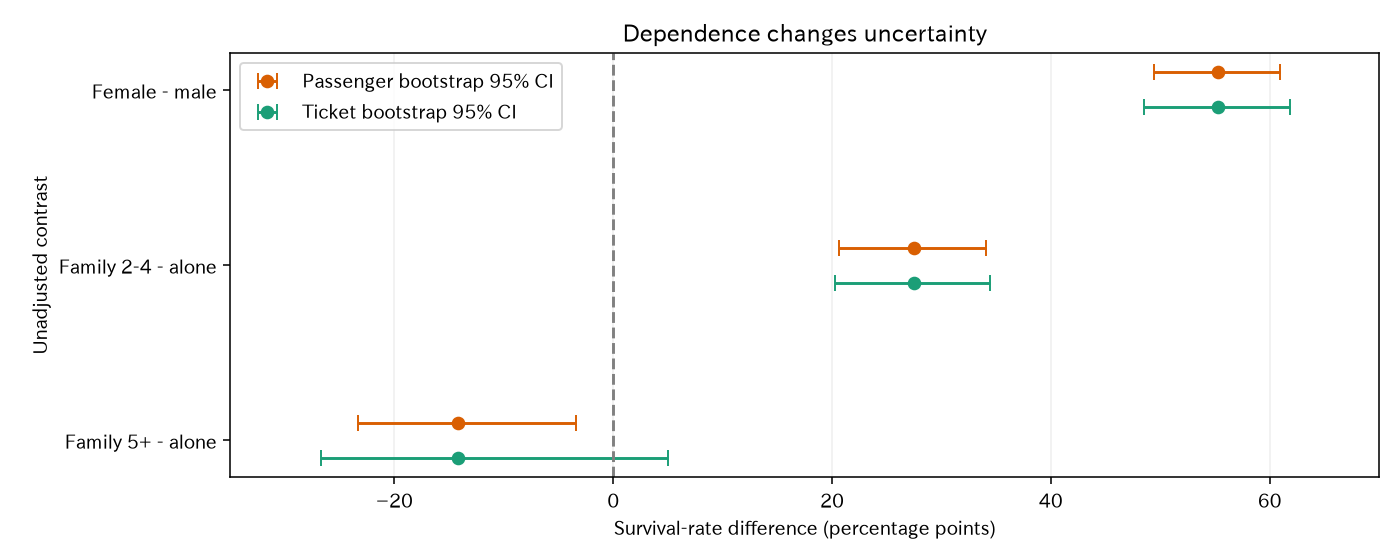

{
  "図4": {
    "title": "Dependence changes uncertainty",
    "xlabel": "Survival-rate difference (percentage points)",
    "ylabel": "Unadjusted contrast",
    "legend": [
      "Passenger bootstrap 95% CI",
      "Ticket bootstrap 95% CI"
    ],
    "missing_glyphs": [],
    "B": 2000,
    "seed": 20261002
  },
  "warnings": []
}

In [19]:
with recorded_cell('chart-bootstrap','図4：依存単位と区間'):
    with warnings.catch_warnings(record=True) as warning_log:
        warnings.simplefilter('always')
        fig,ax=plt.subplots(figsize=(10,4))
        contrast_order=['female_minus_male','family_2to4_minus_alone','family_5plus_minus_alone']
        for unit,offset,color in [('Passenger',-.1,'#d95f02'),('Ticket',.1,'#1b9e77')]:
            table=bootstrap_table[bootstrap_table.unit==unit].set_index('contrast').loc[contrast_order]
            ax.errorbar(100*table.point,np.arange(3)+offset,xerr=np.vstack([100*(table.point-table.ci_low),100*(table.ci_high-table.point)]),fmt='o',capsize=4,color=color,label=unit+' bootstrap 95% CI')
        ax.axvline(0,color='grey',linestyle='--')
        ax.set(yticks=np.arange(3),yticklabels=['Female - male','Family 2-4 - alone','Family 5+ - alone'],xlabel='Survival-rate difference (percentage points)',ylabel='Unadjusted contrast',title='Dependence changes uncertainty',xlim=(-35,70))
        ax.invert_yaxis(); ax.grid(axis='x',alpha=.2); ax.legend(); fig.tight_layout()
        buffer=io.BytesIO();fig.savefig(buffer,format='png',dpi=140);plt.close(fig)
    glyphs=sorted(set(int(m.group(1)) for w in warning_log for m in [re.search(r'Glyph (\d+)',str(w.message))] if m))
    chart_meta={'title':'Dependence changes uncertainty','xlabel':'Survival-rate difference (percentage points)','ylabel':'Unadjusted contrast',
                'legend':['Passenger bootstrap 95% CI','Ticket bootstrap 95% CI'],'missing_glyphs':glyphs,'B':B,'seed':SEED}
    write_notebook(lambda nb:next(c for c in nb.cells if c.id=='chart-bootstrap').metadata.update({'chart':chart_meta}),'図4監査メタデータ')
    display(visualization.build_image_output(buffer.getvalue()).data,raw=True)
    emit({'図4':chart_meta,'warnings':[str(w.message) for w in warning_log]})


In [20]:
with recorded_cell('final-results','最終結果の集約'):
    final_results={'source':provenance,'n':len(df),'survival_counts':df.Survived.value_counts().to_dict(),
                   'primary':initial_metrics,'age_and_sex_sensitivity':iteration1_metrics,
                   'adjustment_sensitivity':iteration2_metrics,'dependence':iteration3_metrics,
                   'schema_violations':[asdict(a) for a in semantic_anomalies],
                   'scope':'descriptive/associational only; no population representativeness or causal identification',
                   'unknown_definition_fields':unknown_fields,'inferred_definition_fields':len(inferred_fields)}
    emit('FINAL_RESULTS='+json.dumps(final_results,ensure_ascii=False,sort_keys=True))


FINAL_RESULTS={"adjustment_sensitivity": {"LogFare_OR_range": [1.1284855011409989, 1.2972832765791393], "port_adjusted_gap": 0.10113695349172645, "port_raw_gap": 0.21661490683229817, "sex_model_gap_max": 0.46576800576985666, "sex_model_gap_min": 0.45910636552962264, "sex_model_max_relative_deviation": 0.014119647955741423, "sex_model_stable": true}, "age_and_sex_sensitivity": {"child_gap_max": 0.22773768340689493, "child_gap_min": 0.158791394872852, "child_max_relative_deviation": 0.23111751866823554, "child_stable": false, "known_age_survival": 0.4061624649859944, "missing_age_survival": 0.2937853107344633, "sex_gap_max": 0.5612644224256197, "sex_gap_min": 0.4885028750863409, "sex_max_relative_deviation": 0.11683905700351174, "sex_stable": true}, "dependence": {"B": 2000, "bootstrap": [{"ci_high": 0.6097084866914056, "ci_low": 0.494265884360224, "contrast": "female_minus_male", "point": 0.5531300709799203, "unit": "Passenger", "width": 0.11544260233118164}, {"ci_high": 0.3405942202270

In [21]:
with recorded_cell('final-insight-record','最終結論と根拠の保存'):
    conclusion=('最終結論：この891人では、生存群は女性が多く、非生存群は男性が多い。女性74.2%対男性18.9%、1等63.0%対3等24.2%という大きな生存率差がある。'
                '女性の差は等級標準化・年齢欠損仕様・説明モデル・Ticket依存検査でも同方向。女性でも3等は50.0%で1等96.8%より低く、性別だけでは説明できない。'
                '生存者の運賃中央値は26.0対10.5と高いが、調整後の運賃関連の区間は無関連を含む。'
                '年齢中央値は両群28歳で、観測された低年齢群の高率は全員に普遍化できず、閾値/欠損感度では大きさの安定基準を満たさない。'
                '家族2–4人の高率は交絡を含み、5人以上の低率は15 Ticketという少数クラスタのため一般的な不利の証拠は不確実。'
                '港・客室記録の差は属性構成や記録欠損の影響を受ける。'
                '根拠：FINAL_RESULTSと各反復の実行済み分母付き表・4図・仕様記録。'
                '限界：競技訓練標本で全乗船者を代表しない、詳細辞書未照合、運賃単位未確認、年齢/客室欠損、共有券を超える依存、小さい層、モデル依存、多重探索。'
                '救命優先や避難経路を測定しておらず機序・因果は説明できない。')
    save_insight('insight-final','final-insight-record',conclusion,'final-results',r'FINAL_RESULTS=(.+)')
    emit({'結論':'標本内で性別・等級の差は大きい。年齢/家族/運賃の解釈には欠損、交絡、依存の留保を付す。','因果主張':False})


{
  "結論": "標本内で性別・等級の差は大きい。年齢/家族/運賃の解釈には欠損、交絡、依存の留保を付す。",
  "因果主張": false
}

## 使用したJupytermindモジュール

以下はNotebookコードで直接importし、記載の関数/クラス/メソッドを直接呼び出したものだけ。内部で呼ばれたモジュールは含めない。

| モジュール | 直接呼び出した関数・クラス・メソッド | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager（pm） | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 指定slug/絶対保存先の解決、データ置場、直列化したセル・出力・metadata保存 |
| ai_data_scientist.language_router | detect_language | 日本語の検出 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | v020-exp-01の協調実行/書込み/終了状態と取消確認 |
| ai_data_scientist.ingestion | SourceSpec, ingest | Kaggle SDK取得CSVの読込みと行数上限 |
| ai_data_scientist.cleaning | clean_dataset | 完全一致重複の検査兼除去、行数影響（0行） |
| ai_data_scientist.eda | explore | 型・欠損・要約・カテゴリ分布 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, manifest.unresolved_fields | 出所/定義/単位の検証・推定・未知を区別 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 分析前提・因果範囲・未解決警告 |
| ai_data_scientist.data_quality | detect_anomalies | 意味的なカテゴリ/値域/非欠損/一意性検査 |
| ai_data_scientist.stats_analysis | correlation | 運賃と生存の点双列相関と日本語解釈 |
| ai_data_scientist.visualization | render_chart, build_image_output | 日本語図とNotebookのPNG MIME出力 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight | 実出力からの引用抽出・根拠検証付きInsight保存 |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 6/6/4仕様の感度分析と相対変動判定 |
| ai_data_scientist.notebook_audit | audit_notebook | 実行/根拠/図表監査（visual_audit=True） |

mcp_gateway、dataset_validation、anomaly_detection、data_quality.validate_anomaliesは未使用。gatewayはPython側MCPClientがないため直接Jupyter MCPツールを使用、独立参照データ検証は参照がないため非適用。統計的z-score除去は正当な高額運賃を異常扱いしかねないため非適用。モデル・ブートストラップはpandas/numpy/scipy/statsmodels/matplotlibでJupyter MCP内だけで実行。Kaggle SDKはauthenticate, dataset_list, dataset_list_files, dataset_download_file, dataset_metadataを直接使用したがJupytermindモジュールではない。

## Jupytermind改善候補

### 候補1：実行中Notebookへのenqueue_writeとMCP保存の協調（統合不足疑い・原因未確定）

- 分類：Jupytermind–Jupyter MCPの協調保存の機能不足候補。Jupytermind単体の不具合と断定しない。
- 再現条件：MCPで実行中のmanifests-qualityセルがdisplay出力後にproject_manager.enqueue_writeでNotebook metadataを書き換える。
- 期待する挙動：metadataとライブセルの実出力/実行番号が共存する。
- 実際の挙動：初回MCP戻り値がoutputs=[], count=0、read_notebookではセル6のexecution_count=N/Aだった一方、カーネルにはdefinition_manifestが存在し、phase_logでexecution/writeのstart/endが完了。初回ログ時刻2026-10-01T15:35:22.865625～15:35:22.884183+00:00。
- 影響：実行済み分析が未実行に見え、根拠・図表・監査が失われ得る。
- 回避策：bootstrapのrecorded_cellで実際のIPython出力をcapture_outputし、実execution_countとMIMEをenqueue_writeで同じセルに明示保存してから再表示。manifests-quality、Insight書込みセル、図表セル、final-auditに適用。偽出力/偽MCPClientは使わない。実行中のセル位置を変更するInsight挿入でも初回Insightが失われることを検出したため、生成Insightは末尾へ追記しコードセル位置を変更しない。完全監査で期待する6 Insightの存在も検査する。
- 関係セル/ログ：bootstrapのrecorded_cell、manifests-quality、final-audit、Notebook metadata.lifecycle_log。保存の再読込/ライブ文書連携のどちらが根本かは別途統合テストが必要。CLI生成やKaggle取得エラー、ベンチマークランナーの不具合とは区別し、MCP/Notebook保存連携を切り分け対象とする。

### 候補2：推定フィールドをまとめて取得するAPI不足（Skill説明との契約差）

- 分類：データ定義manifestの機能不足/ガイダンス差。
- 再現条件：FieldValue(status='inferred')の列定義をbuild_manifestに渡し、manifest.unresolved_fields()を呼ぶ。
- 期待する挙動：Skillが要求するunknown/inferred両方の注意点を標準APIで取得できる、またはunknown限定であることをガイダンスに明示。
- 実際の挙動：APIはunknownだけ返すため、Ageの年単位や家族定義等のinferred項目は戻り値に含まれない（manifests-qualityのunknown_fieldsとinferred_fields_caveatが証拠）。API自身のdocstringはunknown限定なので実装バグと断定しない。
- 影響：APIだけを使うと推定定義の注意が漏れ得る。
- 回避策：variablesを明示走査しinferred_fieldsを併記。推定をverifiedへ格上げしない。
- 関係セル/ログ：manifests-quality、final-results、metadata.data_definition_manifest。Kaggle SDKやCLI、未使用のベンチマークランナーとは無関係。

### 別系統の制約（改善候補と混同しない）

初期Jupyter MCP use_notebookは親ディレクトリを自動作成しなかったため、Jupyter MCP内でmkdirし接続した。filesystem MCPは別の許可ルートでAccess deniedとなり使用中止。これは実行環境/ツール設定の制約でJupytermind候補に含めない。Kaggle SDKのdataset_view未搭載とmetadataのinfoラッパーはSDK仕様で、対応済み。CLI固有の出力サイズ制限は表示上の制約で、保存されたNotebook結果の欠損とは別。ベンチマークランナーは起動していない。

## 再実行と完了監査の手順

すべてのコードセルの出力とexecution_countをクリアした後、Jupyter MCPでカーネルを再起動し、セルの上から順にexecute_cellで再実行する。Notebook内部からexec/subprocess/外部スクリプトを使って再実行しない。API取得も再実行し、初回保存SHA-256/slugとの一致を検査する。Insightは同じIDで再作成し、新しい実行番号と実出力に再結合する。

final-auditは保存済み全セルを再読込み、全コード実行、昇順execution_count、エラーなし、根拠解決、4枚のPNG、字体/タイトル/軸/凡例と非空画像、run_idのquiescenceを確認する。visual_auditは圧縮バイト密度の近似で厳密な画像理解ではないため、4図も目視しラベル・密度軸・共通率軸・負差と0線・区間の重なりを確認した。最終状態はNotebook metadata.final_lifecycle_status / notebook_audit / replay_verificationとセル出力に保存する。

In [22]:
from ai_data_scientist import notebook_audit
with recorded_cell('final-audit','Notebook最終監査'):
    emit('自身の実行記録を保存した後に全セル・全根拠・全図を監査する。')
# recorded_cellによって自身の実行番号・実出力が保存された後、除外なしでもう一度監査する。
final_audit=notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
if not final_audit.ok or final_audit.unexecuted_cell_indices or final_audit.error_cell_indices or final_audit.visual_findings:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('保存後の完全監査/図表監査に失敗。')
finished_nb=nbformat.read(handle.notebook_path,as_version=4)
code_cells=[c for c in finished_nb.cells if c.cell_type=='code']
code_ids=[c.id for c in code_cells]
execution_counts=[c.execution_count for c in code_cells]
if len(final_audit.chart_cell_indices)!=4 or final_audit.insight_cell_count!=6:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('期待した4図と一致しません。')
quantitative_signature={'n':len(df),'primary':initial_metrics,'iteration1':iteration1_metrics,
                        'iteration2':iteration2_metrics,'iteration3':iteration3_metrics}
previous_signature=finished_nb.metadata.get('first_pass_signature')
replay_prepared=bool(finished_nb.metadata.get('replay_prepared',False))
if replay_prepared:
    if code_ids!=finished_nb.metadata['replay_expected_ids'] or execution_counts!=sorted(execution_counts) or len(set(execution_counts))!=len(execution_counts):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('全コードセルの上から順の再実行を確認できません。')
    def compare_numeric(a,b):
        if isinstance(a,dict):
            return set(a)==set(b) and all(compare_numeric(a[k],b[k]) for k in a)
        if isinstance(a,list):
            return len(a)==len(b) and all(compare_numeric(x,y) for x,y in zip(a,b))
        if isinstance(a,(int,float)) and not isinstance(a,bool):
            return bool(np.isclose(a,b,rtol=1e-8,atol=1e-10))
        return a==b
    if previous_signature is None or not compare_numeric(previous_signature,quantitative_signature):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('初回と再実行の数値結果が一致しません。')
replay_verification={'performed':replay_prepared,'method':'Jupyter MCP restart_notebook + ordered execute_cell; outputs/counts cleared before restart',
                     'code_cell_ids':code_ids,'execution_counts':execution_counts,
                     'all_code_executed':final_audit.executed_code_cell_count==final_audit.code_cell_count,
                     'top_to_bottom':execution_counts==sorted(execution_counts),
                     'numerical_match_to_first_pass':True if replay_prepared else 'first pass baseline',
                     'sha256_same_as_first_acquisition':finished_nb.metadata['provenance']['sha256']==provenance['sha256']}
quiescent=lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
if quiescent.active_cell_executions or quiescent.pending_notebook_writes or quiescent.locks_held:
    lifecycle.mark_failed(RUN_ID)
    raise RuntimeError('ライフサイクルが静止状態ではありません。')
final_assumptions=analysis_assumptions.AnalysisAssumptionManifest(
    analysis_scope={'population':'取得した891行','scope':'descriptive/associational','independence':'Ticket proxy cluster sensitivity performed'},
    assumptions=assumption_manifest.assumptions+(
        analysis_assumptions.Assumption('ticket-sensitivity','681券単位再標本化、2000反復、1券除外とモデルの券クラスタ区間を実行','tested',conclusion_critical=True),
        analysis_assumptions.Assumption('missing-sensitivity','年齢閾値/中央値補完/完全症例/極端欠損割当てを検査。MNAR自体は識別しない','tested',conclusion_critical=True),
        analysis_assumptions.Assumption('model-sensitivity','4仕様は収束/有限値/フルランク。未測定交絡やモデル正しさの保証ではない','tested',conclusion_critical=True)),
    causal_scope='associational',sampling={'n':len(df),'seed':SEED,'method':'元データ全行、Ticket感度2000反復'})
final_assumption_findings=analysis_assumptions.check_manifest(final_assumptions)
lifecycle.mark_completed(RUN_ID)
final_status=asdict(lifecycle.get_run_status(RUN_ID))
payload={'run_id':RUN_ID,'lifecycle':final_status,'notebook_audit':asdict(final_audit),'audit_ok':final_audit.ok,
         'visual_audit':True,'replay_verification':replay_verification,
         'assumption_findings':[asdict(f) for f in final_assumption_findings],
         'assumption_caveats_ja':['詳細列定義は独立辞書で未照合（semantic-coding）。','単純率区間の独立性は仮定。Ticket感度は実施したが、真の同行/救命艇依存は不明（independent-passengers）。']}
final_text=json.dumps(payload,ensure_ascii=False,indent=2,default=str)
def save_completion(nb):
    if previous_signature is None:
        nb.metadata['first_pass_signature']=quantitative_signature
    nb.metadata['notebook_audit']={**asdict(final_audit),'ok':final_audit.ok,'visual_audit':True}
    nb.metadata['replay_verification']=replay_verification
    nb.metadata['final_lifecycle_status']=final_status
    nb.metadata['lifecycle_log']=phase_log
    nb.metadata['final_analysis_assumption_manifest']=asdict(final_assumptions)
    nb.metadata['final_assumption_findings']=[asdict(f) for f in final_assumption_findings]
    current=next(c for c in nb.cells if c.id=='final-audit')
    current.outputs.append(nbformat.v4.new_output('display_data',data={'text/plain':final_text}))
write_notebook(save_completion,'最終監査・静止終了状態保存')
emit(payload)


自身の実行記録を保存した後に全セル・全根拠・全図を監査する。

{
  "run_id": "v020-exp-01",
  "lifecycle": {
    "run_id": "v020-exp-01",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb",
    "reason": null
  },
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-01-titanic/notebooks/kaggle-v020-kaggle-exp-01-titanic.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 21,
    "executed_code_cell_count": 21,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      12,
      13,
      14,
      24
    ],
    "insight_cell_count": 6,
    "findings": [],
    "visual_findings": []
  },
  "audit_ok": true,
  "visual_audit": true,
  "replay_verification": {
    "performed": true,
    "method": "Jupyter MCP restart_notebook + or

初回Insight：生存342人/非生存549人。女性生存率74.2%（233/314）、男性18.9%（109/577）で55.3ポイント差。生存群の68.1%が女性、非生存群の85.2%が男性。1等63.0%、2等47.3%、3等24.2%で、女性1等96.8%/3等50.0%、男性1等36.9%/3等13.5%。性別差はどの等級でも同方向で、性別と等級は併せて見る必要がある。生存群の運賃中央値26.0、非生存群10.5だが、高い運賃を払うことが生存を増やすという因果主張ではない。観測年齢中央値は両群28歳で、単一の平均年齢差では分布や乳幼児の違いを表せない。2–4人の家族代理群57.9%、単独30.4%、5人以上16.1%という非線形パターンも、性別・等級構成との交絡が未解決。乗船港・客室記録の差も記録欠損と交絡を含む。根拠：initial-comparisonsの分母付き比較表、構成表、INITIAL_METRICS。

```evidence
{"execution_count":7,"cited_value":"{\"\u5973\u6027\u751f\u5b58\u7387_pct\": 74.20382165605095, \"\u5e74\u9f62\u6b20\u640d_pct\": 19.865319865319865, \"\u6027\u5225\u5dee_pp\": 55.31300709799203, \"\u751f\u5b58\u7fa4\u904b\u8cc3\u4e2d\u592e\u5024\": 26.0, \"\u7537\u6027\u751f\u5b58\u7387_pct\": 18.890814558058924, \"\u7b49\u7d1a1\u751f\u5b58\u7387_pct\": 62.96296296296296, \"\u7b49\u7d1a3\u751f\u5b58\u7387_pct\": 24.236252545824847, \"\u975e\u751f\u5b58\u7fa4\u904b\u8cc3\u4e2d\u592e\u5024\": 10.5}","claim_type":"associational"}
```

相関係数は 0.2573 (p=6.12e-15) で、弱い正の相関が見られます。 運賃と二値生存の点双列相関。外れ値、交絡、共有券依存、非無作為標本を考慮していないため、小さいp値だけで実質的・因果的な重要性は判断しない。

```evidence
{"execution_count":7,"cited_value":"0.2573065223849624","claim_type":"associational"}
```

反復1結果：女性−男性の生存率差は年齢観測/欠損と等級標準化を変えて48.9–56.1ポイントで、事前の相対変動20%基準ではstable=True、max_relative_deviation=0.11683905700351174。主要な性別差はこの範囲では安定。一方、子ども対それ以上の年齢群の差は閾値12/16/18歳と欠損処理で15.9–22.8ポイント、stable=False、max_relative_deviation=0.23111751866823554。方向は正でも大きさは安定と呼べない。年齢欠損群29.4%対観測群40.6%で、欠損は3等に多く完全症例は選択された部分集団。欠損全員を子どもとする非現実的ストレスでは差が−1.7ポイントになり、欠損年齢が不明なまま全員に普遍化はできない。男性の12歳未満は各等級で比較群より高いが、女性1等の子どもは1人で0%、小標本から例外や機序を説明しない。根拠：iteration-1の生存率表、欠損構成、6+6仕様と極端割当て。残る限界：詳細定義、MNAR欠損、共有券依存、層内の小標本。次に運賃や家族・記録項目の交絡を検討する価値がある。

```evidence
{"execution_count":13,"cited_value":"{\"child_gap_max\": 0.22773768340689493, \"child_gap_min\": 0.158791394872852, \"child_max_relative_deviation\": 0.23111751866823554, \"child_stable\": false, \"known_age_survival\": 0.4061624649859944, \"missing_age_survival\": 0.2937853107344633, \"sex_gap_max\": 0.5612644224256197, \"sex_gap_min\": 0.4885028750863409, \"sex_max_relative_deviation\": 0.11683905700351174, \"sex_stable\": true}","claim_type":"associational"}
```

反復2結果：性別×等級の交互作用、年齢二次項、家族代理群、港、客室記録、log(1+運賃)を含む説明GLMで、性別を置き換えた予測値の平均差は45.9–46.6ポイント。4仕様のstable=True、max_relative_deviation=0.014119647955741423。これは共変量分布上の記述的な予測対比で、性別の因果効果ではない。運賃のORはlog(1+Fare)が1増加するごとに1.13–1.30で、共有Ticketクラスタ95%区間は全仕様で1を含む。生存群の高い粗運賃から、支払いを増やせば生存しやすいとは結論できない。C−S港の粗差21.7ポイントは共通の性別×等級構成で10.1ポイントに縮む。Q港は層別に極小標本で全体調整の解釈を保留。2–4人家族群の粗い優位と客室記録ありの粗差も、調整GLMでは明確な追加的関連と呼べず、大人数家族の低さは共有券依存に注意が必要。根拠：iteration-2の層別表、C/S直接標準化、4モデル係数/クラスタ区間、ITERATION2_METRICS。モデルでは乗船港欠損2人を除外（全行比較は891人を維持）、中央値補完889人/完全症例712人。残る限界：モデル形の制約、単一補完、層内支持不足、港・客室記録の測定/選択バイアス、共有券以外の依存。点推定が安定でも区間の校正や因果識別を保証しない。最後にクラスタ再標本化で主要差と家族差を検証する。

```evidence
{"execution_count":15,"cited_value":"{\"LogFare_OR_range\": [1.1284855011409989, 1.2972832765791393], \"port_adjusted_gap\": 0.10113695349172645, \"port_raw_gap\": 0.21661490683229817, \"sex_model_gap_max\": 0.46576800576985666, \"sex_model_gap_min\": 0.45910636552962264, \"sex_model_max_relative_deviation\": 0.014119647955741423, \"sex_model_stable\": true}","claim_type":"associational"}
```

反復3結果：女性−男性の粗差55.3ポイントのTicketブートストラップ95%区間は48.5–61.9ポイントで、乗客単位の49.4–61.0より広いが0を大きく上回る。1券除外の差は55.0–56.4ポイント、最大変化1.14ポイントで主要差は少数券だけで説明されない。2–4人家族代理群−単独の粗差27.5ポイントはTicket区間20.3–34.4だが、反復2から追加的・因果的な家族効果とは呼ばない。5人以上−単独の粗差−14.2ポイントは、乗客単位区間−23.3～−3.4からTicket区間−26.7～+5.0へ拡がり0を含む。この群の62人は15 Ticketしかなく、1券除外で最大4.06ポイント変化する。標本内の低率は事実だが、「大人数家族は一般に不利」の証拠は単純独立区間が示すほど強くない。根拠：iteration-3の2000反復（seed=20261002）、群別券数、全681券のleave-one-ticket。残る限界：Ticketを超える依存、有限反復・percentile近似、非無作為訓練標本、家族代理の測定と交絡。再読後の停止理由：主要性別差と等級の記述、年齢欠損、運賃/家族/港/客室記録の交絡、依存による区間の変化を検討済み。未解決の詳細定義・歴史的記録・代表性・真の同行集団は同じCSVの再分析だけでは解決できない。追加モデルの探索は解釈より恣意性を増すため追加価値は小さく、最大3反復で停止する。

```evidence
{"execution_count":17,"cited_value":"{\"B\": 2000, \"bootstrap\": [{\"ci_high\": 0.6097084866914056, \"ci_low\": 0.494265884360224, \"contrast\": \"female_minus_male\", \"point\": 0.5531300709799203, \"unit\": \"Passenger\", \"width\": 0.11544260233118164}, {\"ci_high\": 0.34059422022709723, \"ci_low\": 0.20641568866912902, \"contrast\": \"family_2to4_minus_alone\", \"point\": 0.27522894824111627, \"unit\": \"Passenger\", \"width\": 0.13417853155796822}, {\"ci_high\": -0.03434936490435261, \"ci_low\": -0.23326650472813293, \"contrast\": \"family_5plus_minus_alone\", \"point\": -0.1422478524659098, \"unit\": \"Passenger\", \"width\": 0.19891713982378031}, {\"ci_high\": 0.6188354778113788, \"ci_low\": 0.4851868289066783, \"contrast\": \"female_minus_male\", \"point\": 0.5531300709799203, \"unit\": \"Ticket\", \"width\": 0.13364864890470052}, {\"ci_high\": 0.3444339883898918, \"ci_low\": 0.20272864413212835, \"contrast\": \"family_2to4_minus_alone\", \"point\": 0.27522894824111627, \"unit\": \"Ticket\", \"width\": 0.14170534425776346}, {\"ci_high\": 0.04982815810715367, \"ci_low\": -0.2669177398208619, \"contrast\": \"family_5plus_minus_alone\", \"point\": -0.1422478524659098, \"unit\": \"Ticket\", \"width\": 0.3167458979280156}], \"leave_one_ticket\": [{\"contrast\": \"female_minus_male\", \"full_point\": 0.5531300709799203, \"leave_one_ticket_max\": 0.5644800900520613, \"leave_one_ticket_min\": 0.5498015318387657, \"max_absolute_shift\": 0.01135001907214106}, {\"contrast\": \"family_2to4_minus_alone\", \"full_point\": 0.27522894824111627, \"leave_one_ticket_max\": 0.28123691145863533, \"leave_one_ticket_min\": 0.2693784916201117, \"max_absolute_shift\": 0.006007963217519063}, {\"contrast\": \"family_5plus_minus_alone\", \"full_point\": -0.1422478524659098, \"leave_one_ticket_max\": -0.12171999322837312, \"leave_one_ticket_min\": -0.18284851987414114, \"max_absolute_shift\": 0.040600667408231345}], \"seed\": 20261002, \"support\": {\"2-4\": {\"max_passengers_per_ticket\": 4, \"passengers\": 292, \"tickets\": 184}, \"5+\": {\"max_passengers_per_ticket\": 7, \"passengers\": 62, \"tickets\": 15}, \"Alone\": {\"max_passengers_per_ticket\": 7, \"passengers\": 537, \"tickets\": 502}, \"female\": {\"max_passengers_per_ticket\": 5, \"passengers\": 314, \"tickets\": 247}, \"male\": {\"max_passengers_per_ticket\": 7, \"passengers\": 577, \"tickets\": 519}}}","claim_type":"associational"}
```

最終結論：この891人では、生存群は女性が多く、非生存群は男性が多い。女性74.2%対男性18.9%、1等63.0%対3等24.2%という大きな生存率差がある。女性の差は等級標準化・年齢欠損仕様・説明モデル・Ticket依存検査でも同方向。女性でも3等は50.0%で1等96.8%より低く、性別だけでは説明できない。生存者の運賃中央値は26.0対10.5と高いが、調整後の運賃関連の区間は無関連を含む。年齢中央値は両群28歳で、観測された低年齢群の高率は全員に普遍化できず、閾値/欠損感度では大きさの安定基準を満たさない。家族2–4人の高率は交絡を含み、5人以上の低率は15 Ticketという少数クラスタのため一般的な不利の証拠は不確実。港・客室記録の差は属性構成や記録欠損の影響を受ける。根拠：FINAL_RESULTSと各反復の実行済み分母付き表・4図・仕様記録。限界：競技訓練標本で全乗船者を代表しない、詳細辞書未照合、運賃単位未確認、年齢/客室欠損、共有券を超える依存、小さい層、モデル依存、多重探索。救命優先や避難経路を測定しておらず機序・因果は説明できない。

```evidence
{"execution_count":20,"cited_value":"{\"adjustment_sensitivity\": {\"LogFare_OR_range\": [1.1284855011409989, 1.2972832765791393], \"port_adjusted_gap\": 0.10113695349172645, \"port_raw_gap\": 0.21661490683229817, \"sex_model_gap_max\": 0.46576800576985666, \"sex_model_gap_min\": 0.45910636552962264, \"sex_model_max_relative_deviation\": 0.014119647955741423, \"sex_model_stable\": true}, \"age_and_sex_sensitivity\": {\"child_gap_max\": 0.22773768340689493, \"child_gap_min\": 0.158791394872852, \"child_max_relative_deviation\": 0.23111751866823554, \"child_stable\": false, \"known_age_survival\": 0.4061624649859944, \"missing_age_survival\": 0.2937853107344633, \"sex_gap_max\": 0.5612644224256197, \"sex_gap_min\": 0.4885028750863409, \"sex_max_relative_deviation\": 0.11683905700351174, \"sex_stable\": true}, \"dependence\": {\"B\": 2000, \"bootstrap\": [{\"ci_high\": 0.6097084866914056, \"ci_low\": 0.494265884360224, \"contrast\": \"female_minus_male\", \"point\": 0.5531300709799203, \"unit\": \"Passenger\", \"width\": 0.11544260233118164}, {\"ci_high\": 0.34059422022709723, \"ci_low\": 0.20641568866912902, \"contrast\": \"family_2to4_minus_alone\", \"point\": 0.27522894824111627, \"unit\": \"Passenger\", \"width\": 0.13417853155796822}, {\"ci_high\": -0.03434936490435261, \"ci_low\": -0.23326650472813293, \"contrast\": \"family_5plus_minus_alone\", \"point\": -0.1422478524659098, \"unit\": \"Passenger\", \"width\": 0.19891713982378031}, {\"ci_high\": 0.6188354778113788, \"ci_low\": 0.4851868289066783, \"contrast\": \"female_minus_male\", \"point\": 0.5531300709799203, \"unit\": \"Ticket\", \"width\": 0.13364864890470052}, {\"ci_high\": 0.3444339883898918, \"ci_low\": 0.20272864413212835, \"contrast\": \"family_2to4_minus_alone\", \"point\": 0.27522894824111627, \"unit\": \"Ticket\", \"width\": 0.14170534425776346}, {\"ci_high\": 0.04982815810715367, \"ci_low\": -0.2669177398208619, \"contrast\": \"family_5plus_minus_alone\", \"point\": -0.1422478524659098, \"unit\": \"Ticket\", \"width\": 0.3167458979280156}], \"leave_one_ticket\": [{\"contrast\": \"female_minus_male\", \"full_point\": 0.5531300709799203, \"leave_one_ticket_max\": 0.5644800900520613, \"leave_one_ticket_min\": 0.5498015318387657, \"max_absolute_shift\": 0.01135001907214106}, {\"contrast\": \"family_2to4_minus_alone\", \"full_point\": 0.27522894824111627, \"leave_one_ticket_max\": 0.28123691145863533, \"leave_one_ticket_min\": 0.2693784916201117, \"max_absolute_shift\": 0.006007963217519063}, {\"contrast\": \"family_5plus_minus_alone\", \"full_point\": -0.1422478524659098, \"leave_one_ticket_max\": -0.12171999322837312, \"leave_one_ticket_min\": -0.18284851987414114, \"max_absolute_shift\": 0.040600667408231345}], \"seed\": 20261002, \"support\": {\"2-4\": {\"max_passengers_per_ticket\": 4, \"passengers\": 292, \"tickets\": 184}, \"5+\": {\"max_passengers_per_ticket\": 7, \"passengers\": 62, \"tickets\": 15}, \"Alone\": {\"max_passengers_per_ticket\": 7, \"passengers\": 537, \"tickets\": 502}, \"female\": {\"max_passengers_per_ticket\": 5, \"passengers\": 314, \"tickets\": 247}, \"male\": {\"max_passengers_per_ticket\": 7, \"passengers\": 577, \"tickets\": 519}}}, \"inferred_definition_fields\": 23, \"n\": 891, \"primary\": {\"\u5973\u6027\u751f\u5b58\u7387_pct\": 74.20382165605095, \"\u5e74\u9f62\u6b20\u640d_pct\": 19.865319865319865, \"\u6027\u5225\u5dee_pp\": 55.31300709799203, \"\u751f\u5b58\u7fa4\u904b\u8cc3\u4e2d\u592e\u5024\": 26.0, \"\u7537\u6027\u751f\u5b58\u7387_pct\": 18.890814558058924, \"\u7b49\u7d1a1\u751f\u5b58\u7387_pct\": 62.96296296296296, \"\u7b49\u7d1a3\u751f\u5b58\u7387_pct\": 24.236252545824847, \"\u975e\u751f\u5b58\u7fa4\u904b\u8cc3\u4e2d\u592e\u5024\": 10.5}, \"schema_violations\": [], \"scope\": \"descriptive/associational only; no population representativeness or causal identification\", \"source\": {\"acquisition\": \"Kaggle Python SDK / dataset_download_file\", \"competition_reference\": \"https://www.kaggle.com/competitions/titanic\", \"dataset_url\": \"https://www.kaggle.com/datasets/yasserh/titanic-dataset\", \"external_csv_mirror\": false, \"filename\": \"Titanic-Dataset.csv\", \"owner_dataset_slug\": \"yasserh/titanic-dataset\", \"retrieved_at_utc\": \"2026-10-01T15:45:35.352734+00:00\", \"sha256\": \"7d118fef8b6ccf7f81111877bc388536f7b1e498a655e3d649d19aaa010e9f6f\"}, \"survival_counts\": {\"0\": 549, \"1\": 342}, \"unknown_definition_fields\": [[\"source.measurement_pathway\", {\"source\": \"\u6b74\u53f2\u7684\u8a18\u9332\u306e\u53ce\u96c6\u30fb\u6539\u8a02\u904e\u7a0b\u306f\u672a\u53d6\u5f97\", \"status\": \"unknown\", \"value\": null}], [\"variables.Fare.unit\", {\"source\": \"https://www.kaggle.com/datasets/yasserh/titanic-dataset\uff08SDK\u516c\u958bdescription\u3001\u5217\u540d\u3068\u5b9f\u6e2c\u5024\uff09\", \"status\": \"unknown\", \"value\": \"\u901a\u8ca8\u5358\u4f4d\u672a\u78ba\u8a8d\"}]]}","claim_type":"associational"}
```